# **Problem Statement**

## Context

A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost, which is beneficial to hotel guests, but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impacts a hotel on various fronts:
1. Loss of resources (revenue) when the hotel cannot resell the room.
2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
3. Lowering prices last minute, so the hotel can resell a room, resulting in a reduction of the profit margin.
4. Human resources to make arrangements for the guests.

## Objective

The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, and they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. As a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which bookings are going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description:

The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.

## Data Dictionary:


- Booking_ID: the unique identifier of each booking
- no_of_adults: Number of adults
- no_of_children: Number of Children
- no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel
- type_of_meal_plan: Type of meal plan booked by the customer:
 - Not Selected – No meal plan selected
 - Meal Plan 1 – Breakfast
 - Meal Plan 2 – Half board (breakfast and one other meal)
 - Meal Plan 3 – Full board (breakfast, lunch, and dinner)
- required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
- room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group
- lead_time: Number of days between the date of booking and the arrival date
- arrival_year: Year of arrival date
- arrival_month: Month of arrival date
- arrival_date: Date of the month
- market_segment_type: Market segment designation.
- repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
- no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
- no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
- avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- booking_status: Flag indicating if the booking was canceled or not.



# **Importing the necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


# To build model for prediction
import statsmodels.api as SM
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

import warnings
warnings.filterwarnings("ignore")

# **Loading the Dataset**

In [ ]:
# Loading the drive
from google.colab import drive # importing/linking the google drive with google colab.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading and displaying the data

path="/content/drive/My Drive/INNHotelsGroup.csv" # Loading the dataset 'INNHotelsGroup.csv' as csv file into google colab.
data = pd.read_csv(path) # Reading the dataset

# **Data Overview**

In [ ]:
data.head() # Displaying the first five rows of the data

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
data.shape # Understanding the shape of the data i.e., no of rows and columns

(36275, 19)

In [ ]:
data.info() # Checking the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

## Statistical summary of the dataset.

In [ ]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN36275,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.0,NaN,NaN,NaN,1.844962,0.518715,0.0,2.0,2.0,2.0,4.0
no_of_children,36275.0,NaN,NaN,NaN,0.105279,0.402648,0.0,0.0,0.0,0.0,10.0
no_of_weekend_nights,36275.0,NaN,NaN,NaN,0.810724,0.870644,0.0,0.0,1.0,2.0,7.0
no_of_week_nights,36275.0,NaN,NaN,NaN,2.2043,1.410905,0.0,1.0,2.0,3.0,17.0
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.0,NaN,NaN,NaN,0.030986,0.173281,0.0,0.0,0.0,0.0,1.0
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.0,NaN,NaN,NaN,85.232557,85.930817,0.0,17.0,57.0,126.0,443.0
arrival_year,36275.0,NaN,NaN,NaN,2017.820427,0.383836,2017.0,2018.0,2018.0,2018.0,2018.0


- no_of_adults & no_of_children : These dependent variables can be treated as category
- no_of_week_nights : Average number of weekdays spent is 2 days with a min range from 1 to maximum of 17 days
- no_of_weekend_nights : Average number of weekends spent is 1 day with a min range from 0 to maximum of 7 days
- lead_time: Average number of days between the date of booking and the arrival date is 57 days with a min of 0 days and a maximum of 443 days. The range of this attribute is very wide and the difference between the 75th percentile and the median value or max value indicates that there might be outliers present in this attribute.
- repeated_guest column shows nil or 1 entry, which can state that this attribute has no significance and can be dropped in our model.
- marget_Segment_type has total 5 unique categories which can be further split into unique columns for data analysis.
- booking_status : Around 24,390 non cancelled bookings are there which indicates a great number of around 11,885 cancelled bookings (as 36,275 - 24,390 = 11,885).


In [ ]:
## Checking for duplicate values
data.duplicated().sum()

np.int64(0)

- There are no duplicates in the data.

In [ ]:
## Checking for missing values
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


- There are no missing values in the data.

## Feature Engineering

In [ ]:
# dropping BookingID
data.drop(["Booking_ID"], axis=1, inplace=True)

## Data modelling

In [ ]:
data["arrival_year"].value_counts() # Checking and counting the people visits by year

,count
arrival_year,
2018,29761
2017,6514


In [ ]:
data["arrival_month"].value_counts() # Checking and counting the people visits by month

,count
arrival_month,
10,5317
9,4611
8,3813
6,3203
12,3021
11,2980
7,2920
4,2736
5,2598


In [ ]:
data["arrival_date"].value_counts().head(10) # Checking and counting the people visits by top 10 dates

,count
arrival_date,
13,1358
17,1345
2,1331
19,1327
4,1327
16,1306
20,1281
6,1273
15,1273


- Most of the people visited or arrived in 2018 and in the months of September and October.
- Also we can observe that most of the people visited 2nd,4th being beginning of the month and 13th,17th,19th dates being a mid of the month.

In [ ]:
# See how much variance is in the columns
print(data["required_car_parking_space"].value_counts(normalize=True))
print(data["repeated_guest"].value_counts(normalize=True))

required_car_parking_space
0    0.969014
1    0.030986
Name: proportion, dtype: float64
repeated_guest
0    0.974363
1    0.025637
Name: proportion, dtype: float64


- **Since one value is dominating the other by more than 95%, we have decided to drop these columns**


In [ ]:
data.drop(["required_car_parking_space", "repeated_guest"], axis=1, inplace=True)

# **Exploratory Data Analysis (EDA)**

## Functions for EDA
The below functions need to be defined to carry out the EDA.

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,) # creating the 2 subplots

    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")  # boxplot will be created and a triangle shows mean value of the column
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins) if bins else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)  # For histogram
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],)

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(100 * p.get_height() / total)
            # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",)  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False)
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False)
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(loc="lower left", frameon=False,)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target = "booking_status"
    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target = " + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target = " + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis - Numerical data:

### Observations on no_of_adults and no_of_children

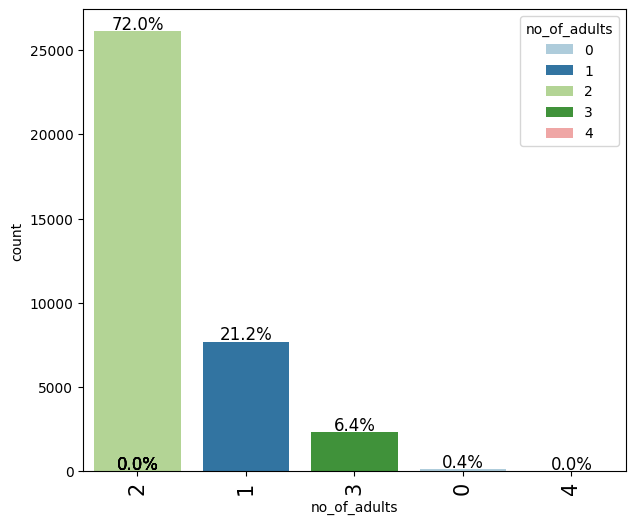

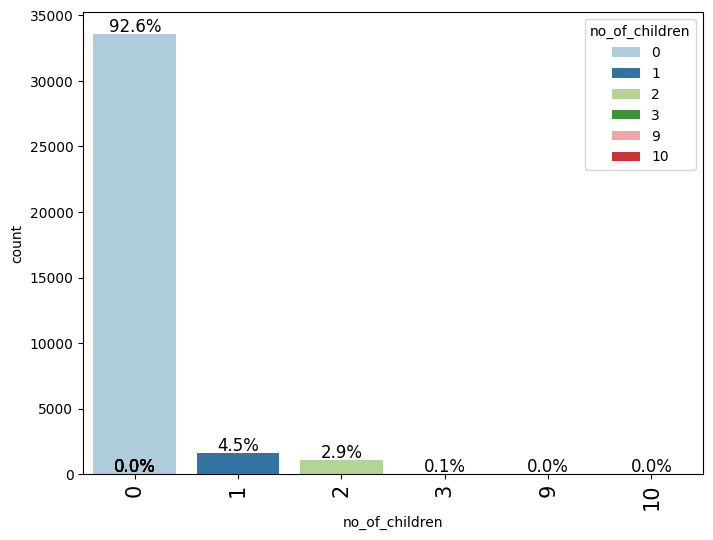

In [ ]:
labeled_barplot(data, "no_of_adults", perc = True)
labeled_barplot(data, "no_of_children", perc = True)

- It can be seen that no_of_adults visiting as 2 people is 72%.
- Around majority ie., 93% of visitors have no children which can be later checked for correlation with other variables and if no significance is seen, this variable can be dropped.

### Observations on no_of_weekend_nights and no_of_week_nights

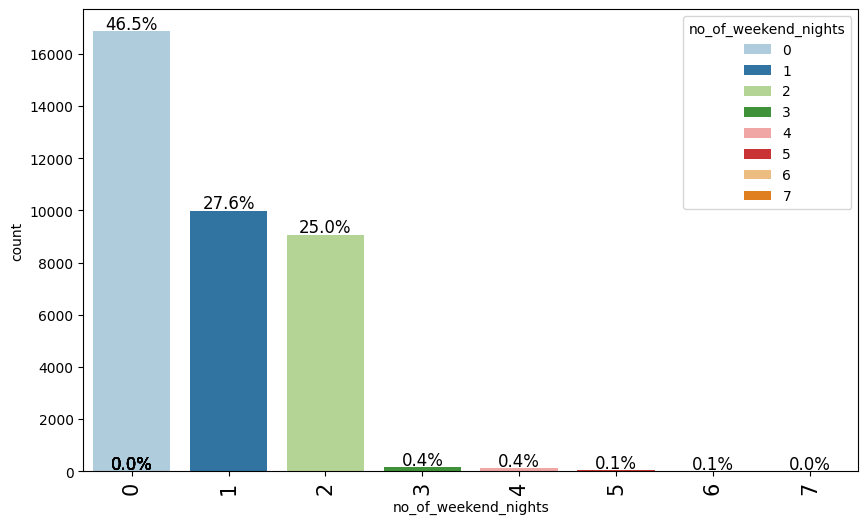

In [ ]:
labeled_barplot(data, "no_of_weekend_nights", perc = True)

- It is evident that around 52% visitors stay for 1 or 2 weekend days

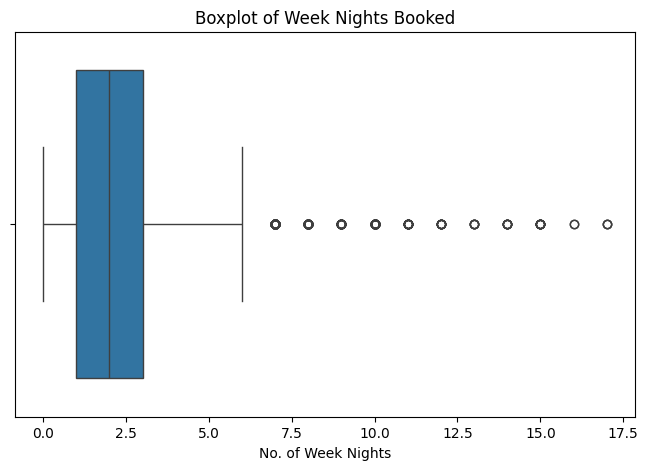

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["no_of_week_nights"])
plt.title("Boxplot of Week Nights Booked")
plt.xlabel("No. of Week Nights")
plt.show()


- Graph shows a lot of data points towards the extreme right, showing the presence of outliers. It is suggested to treat the outliers as the data is heavily right skewed.

### Observations on lead_time

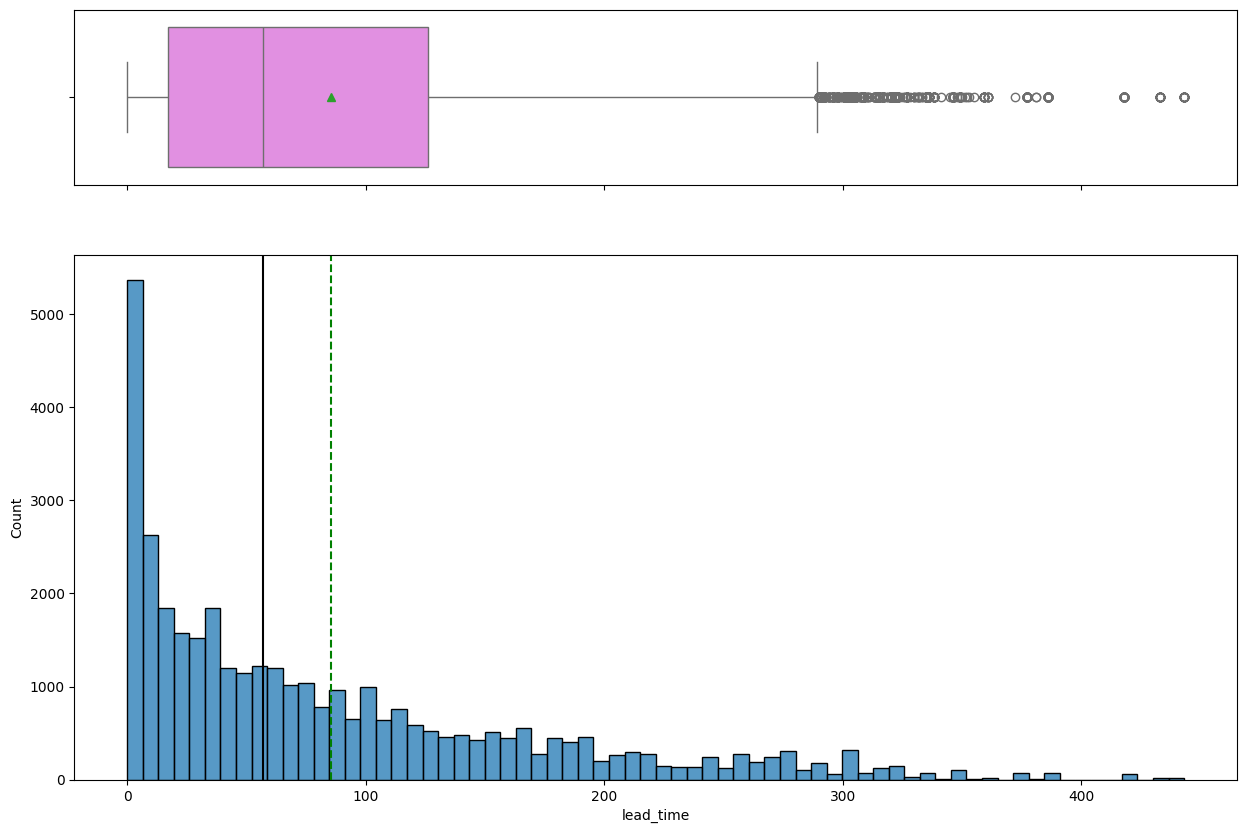

In [ ]:
histogram_boxplot(data, "lead_time")

- Graph shows a lot of data points towards the extreme right, showing the presence of outliers. It is suggested to treat the outliers as the data is heavily right skewed.

### Observations on arrival_year, arrival_month, arrival_date

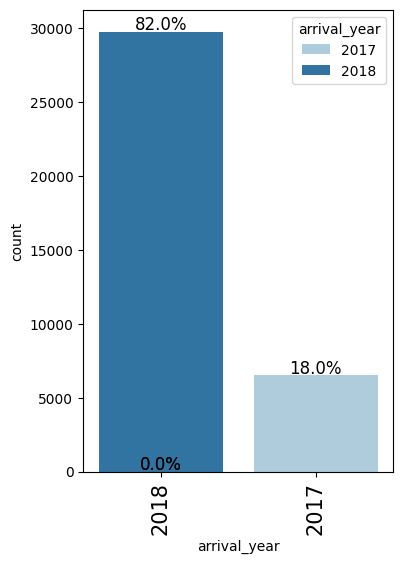

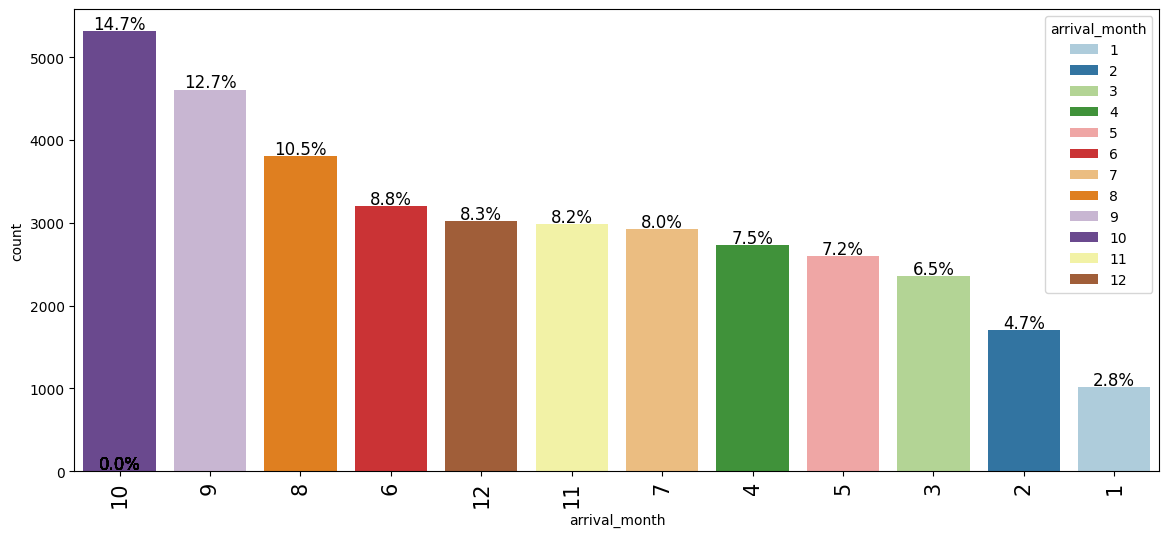

In [ ]:
labeled_barplot(data, "arrival_year", perc = True)
labeled_barplot(data, "arrival_month", perc = True)

- 82% of the visitors visited in 2018 amongst which most of them visited during September and October.
- Hence busiest months in the hotel are October, september and August.

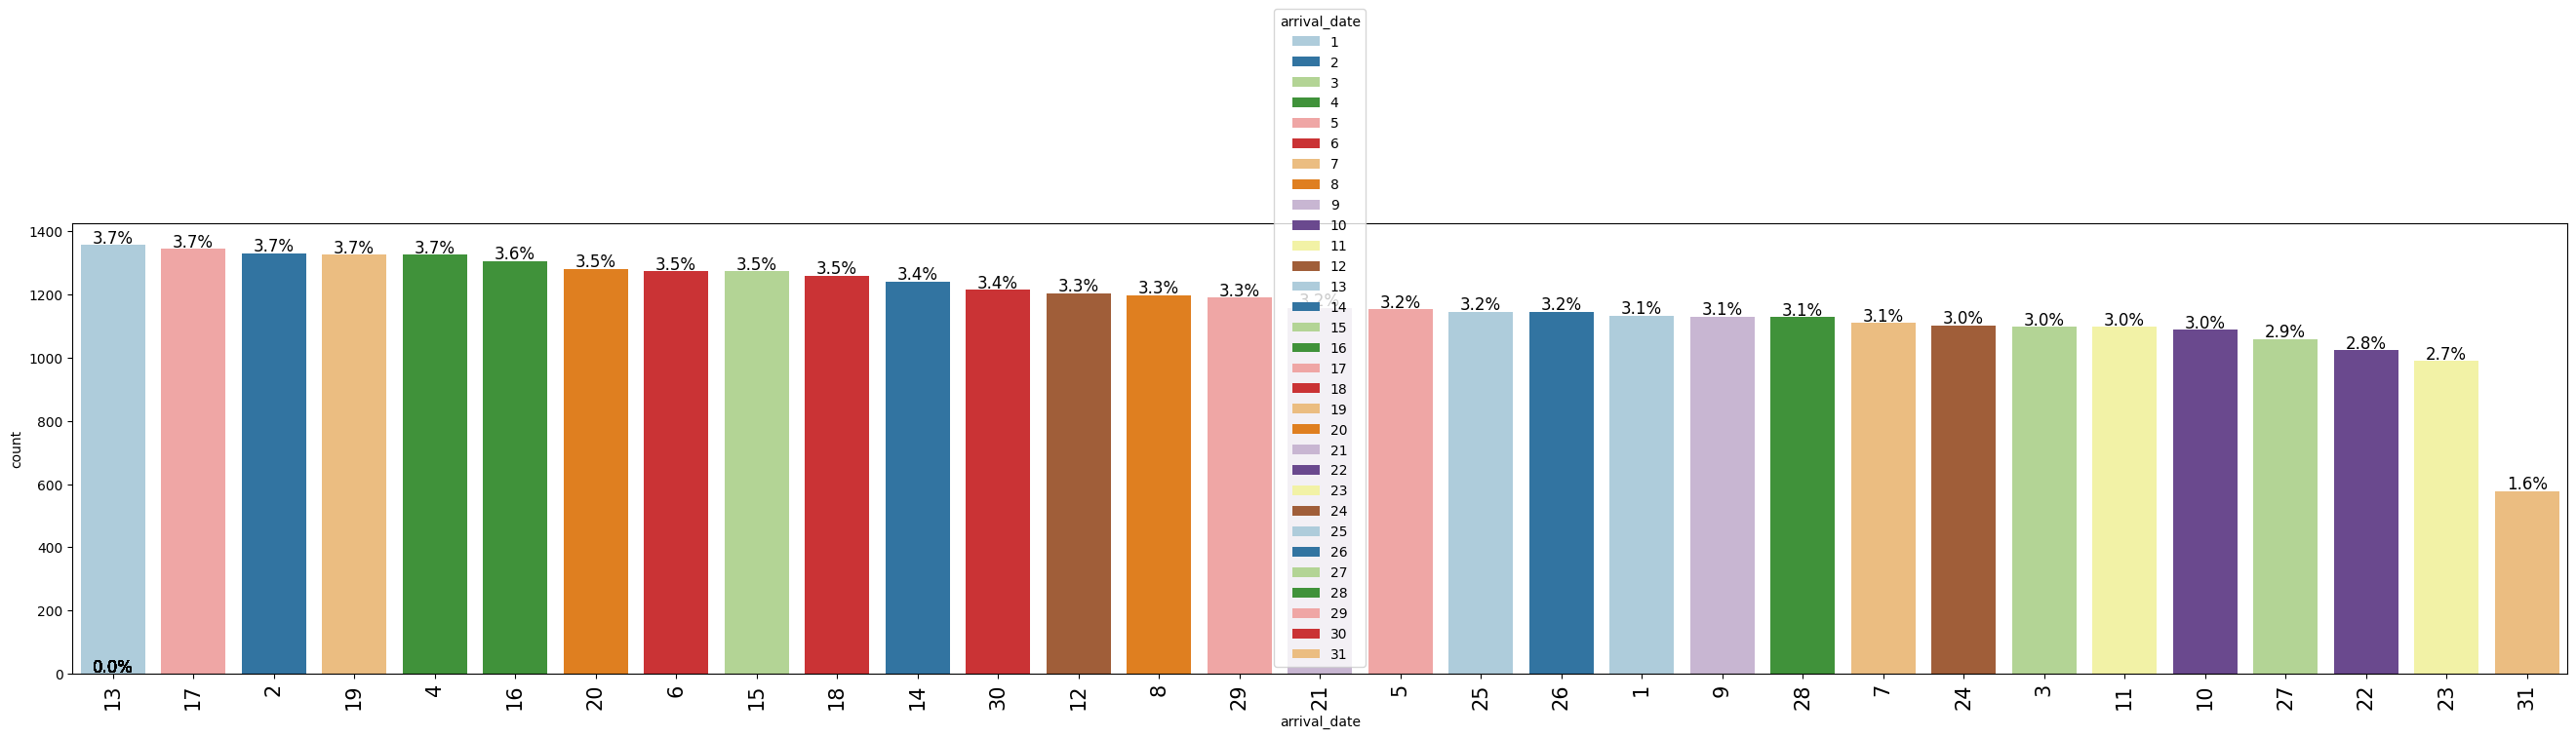

In [ ]:
labeled_barplot(data, "arrival_date", perc = True)

### Observations on avg_price_per_room

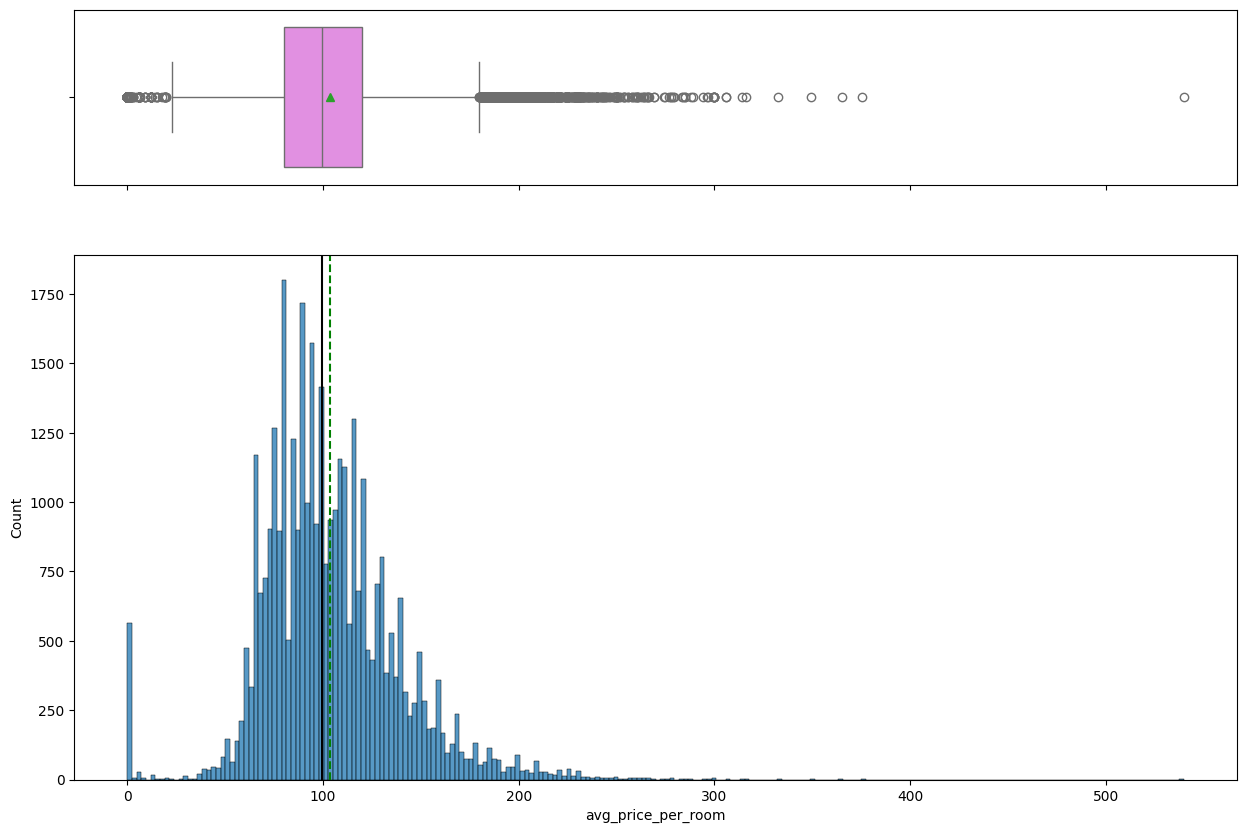

In [ ]:
histogram_boxplot(data, "avg_price_per_room")

- Data shows extreme outliers at both the end and cab be treated.

### Observations on no_of_special_requests

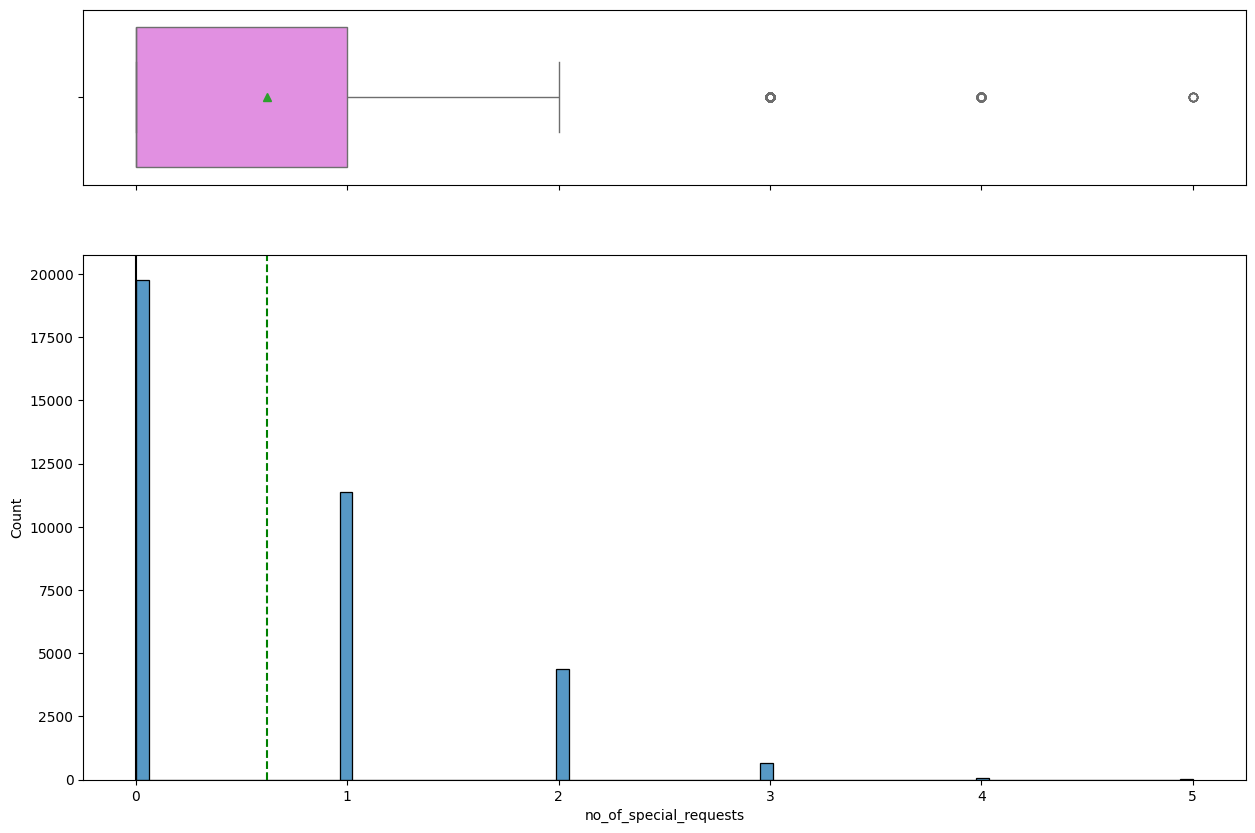

In [ ]:
histogram_boxplot(data, "no_of_special_requests")

-Data shows extreme outliers at both the end and cab be treated.

### Observations on type_of_meal_plan

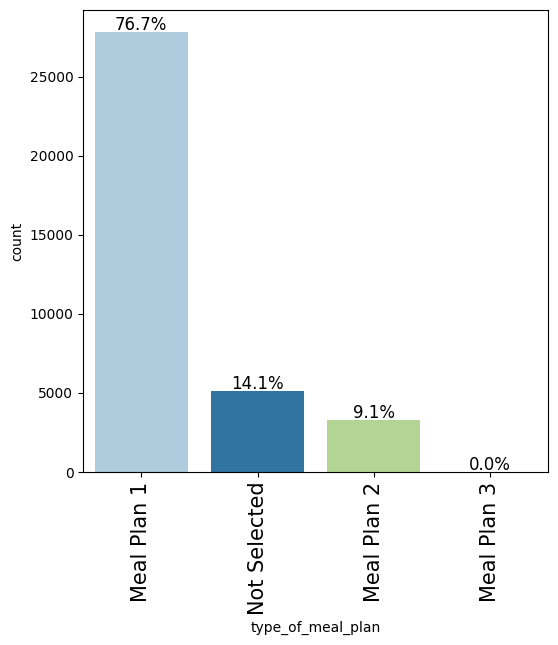

In [ ]:
labeled_barplot(data, "type_of_meal_plan", perc = True)

### Observations on room_type_reserved

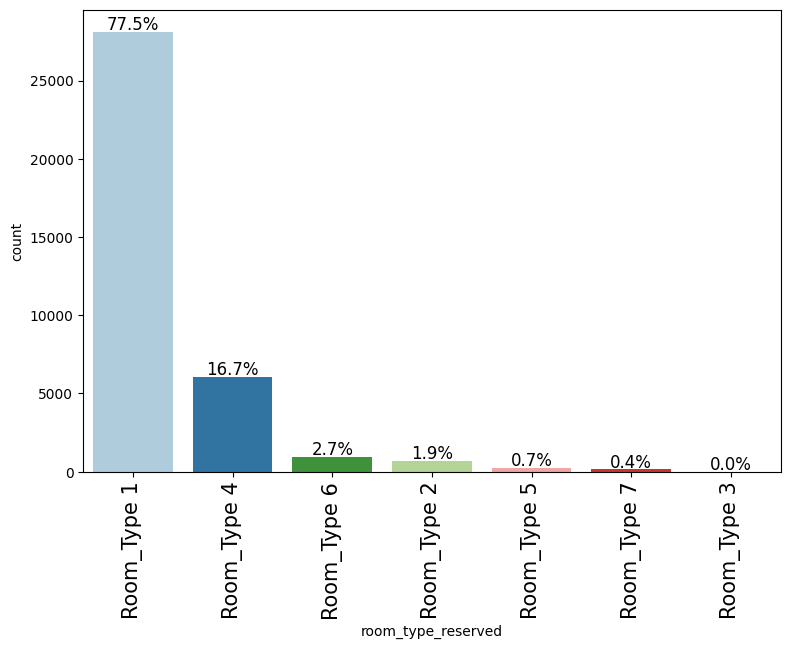

In [ ]:
labeled_barplot(data, "room_type_reserved", perc = True)

### Observations on market_segment_type

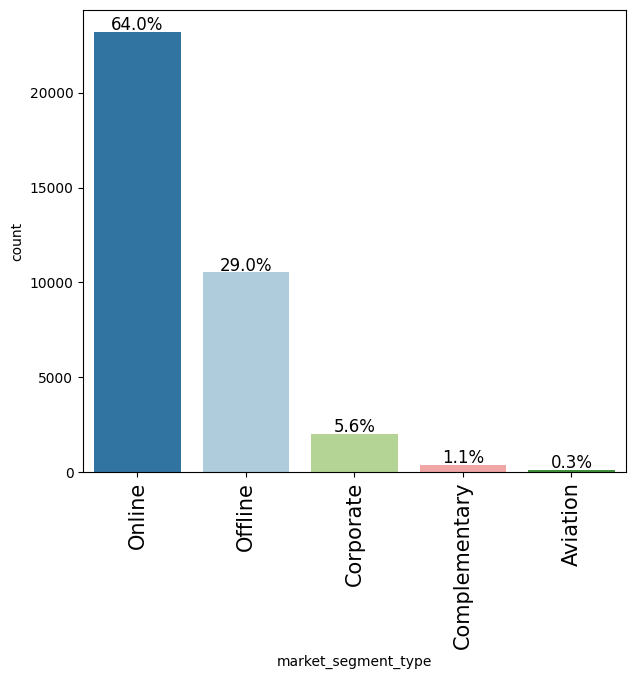

In [ ]:
labeled_barplot(data, "market_segment_type", perc = True)

- Most of the guests come from online market segment

### Observations on booking_status

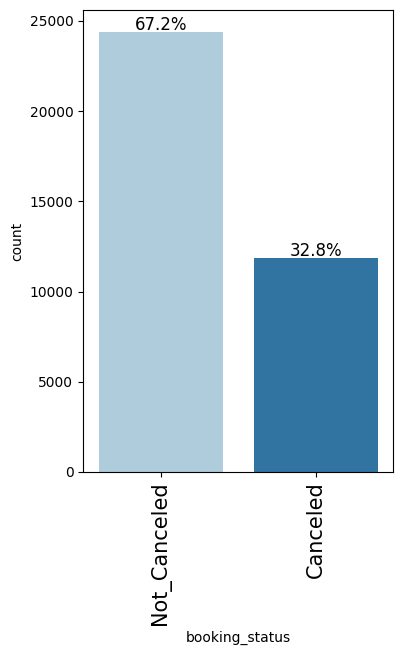

In [ ]:
labeled_barplot(data, "booking_status", perc = True)

- **32% of the people who booked have cancelled their rooms**
- **Hence it is better to study the correlation of this variable with other variables to understand what other variables affect this variable**

### Observations on room prices across segments

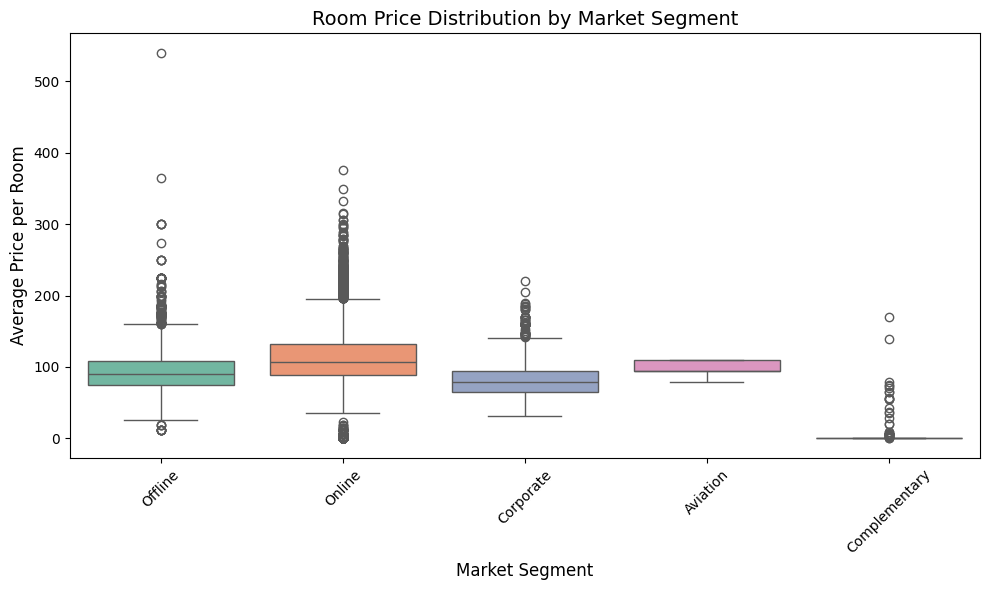

In [ ]:
# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data,  # replace with your actual DataFrame name
    x="market_segment_type",
    y="avg_price_per_room",
    palette="Set2")

# Enhance readability
plt.title("Room Price Distribution by Market Segment", fontsize=14)
plt.xlabel("Market Segment", fontsize=12)
plt.ylabel("Average Price per Room", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Rooms booked online and offline have higher prices compared to corporate and other market segments

## Bivariate Analysis

### Correlation Analysis

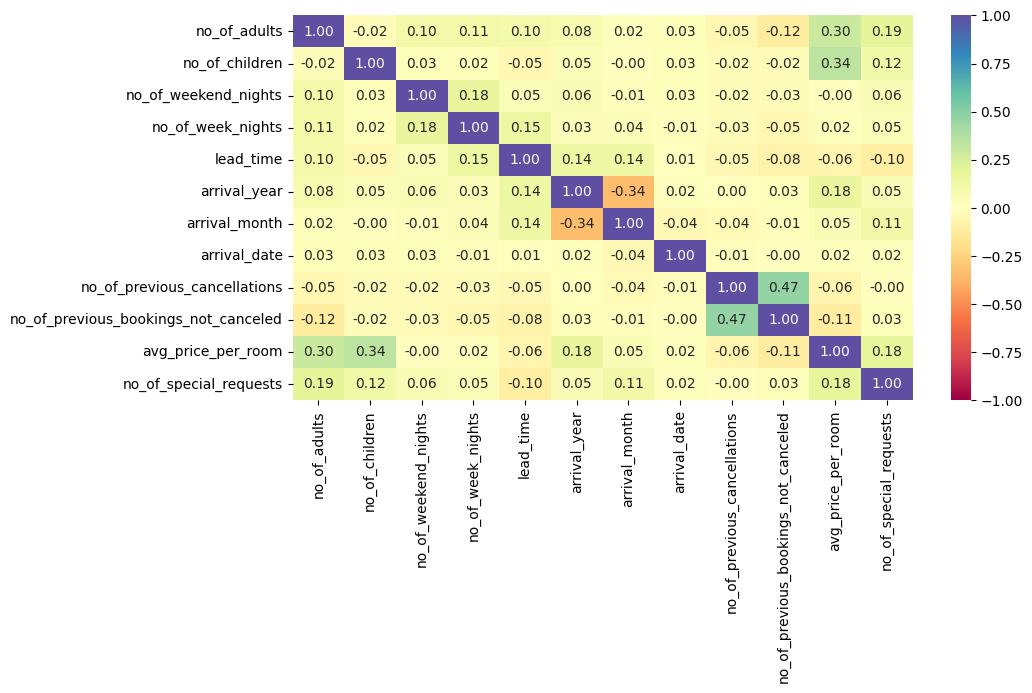

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- no_of_adults vs avg_price_per_room indicates more adults often mean bigger or pricier room types
- lead_time is not strongly correlated with most variables—this could be an independent predictor of cancellations.
- no_of_previous_cancellations and no_of_previous_bookings_not_canceled have a moderate positive correlation 0.47, meaning customers with more booking history show both types of behavior.


### Observations on booking_status vs type_of_meal_plan

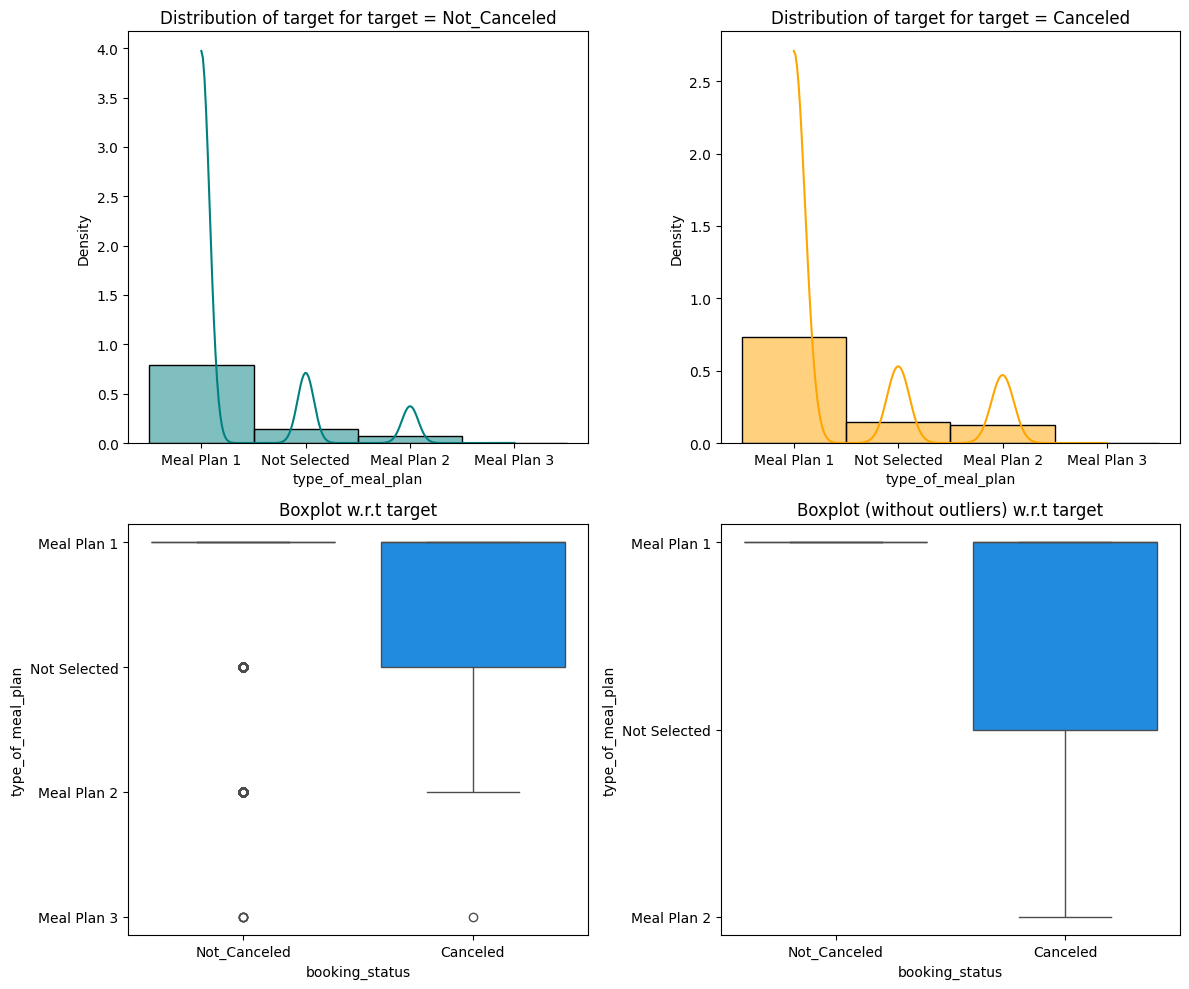

In [ ]:
distribution_plot_wrt_target(data, "type_of_meal_plan")

- There is no relationship between booking_status and type_of_meal_plan

### Observations on booking_status vs room_type_reserved

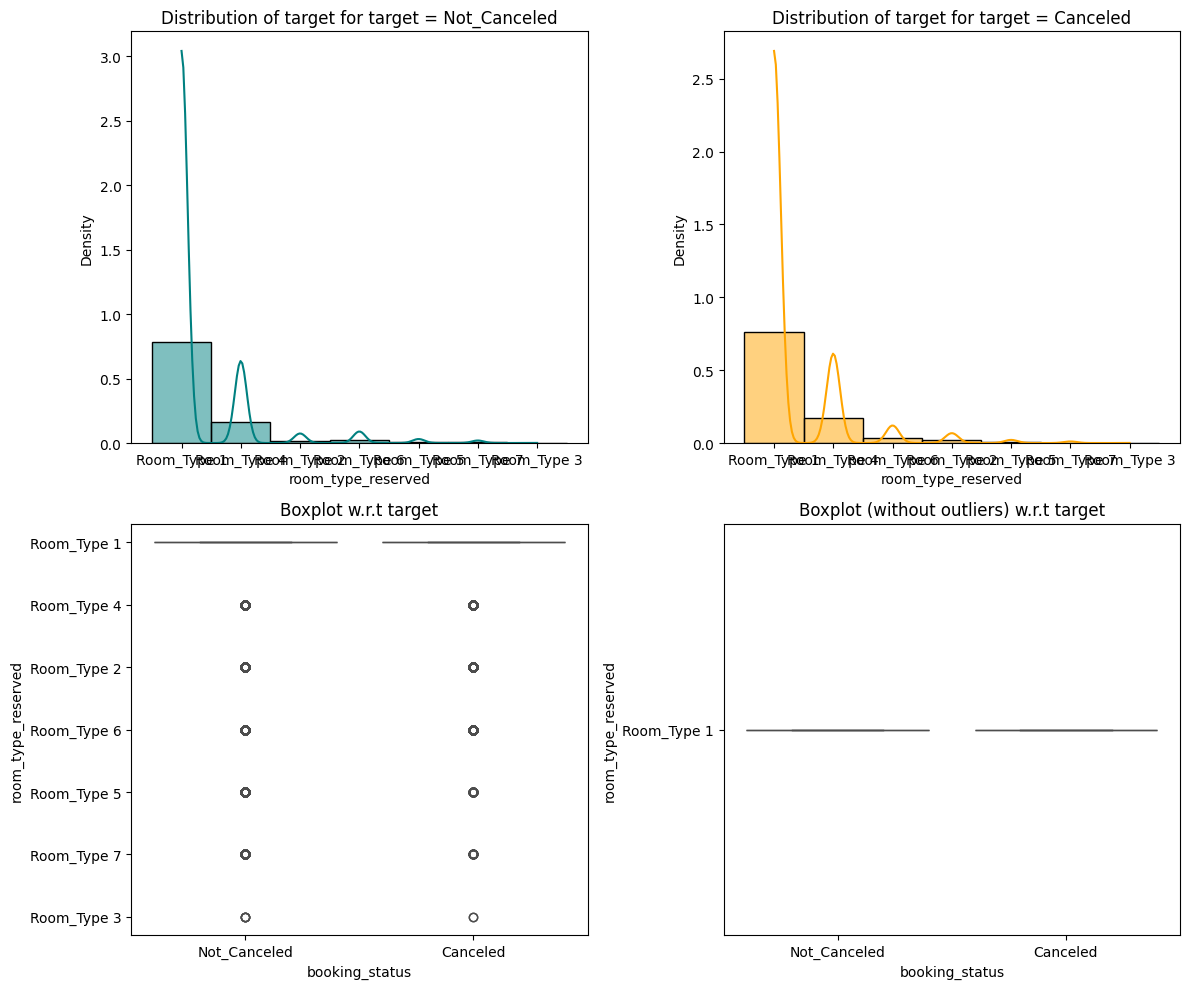

In [ ]:
distribution_plot_wrt_target(data, "room_type_reserved")

- There is no relationship between booking_status and room type

### Observations on booking_Status vs market_segment_type

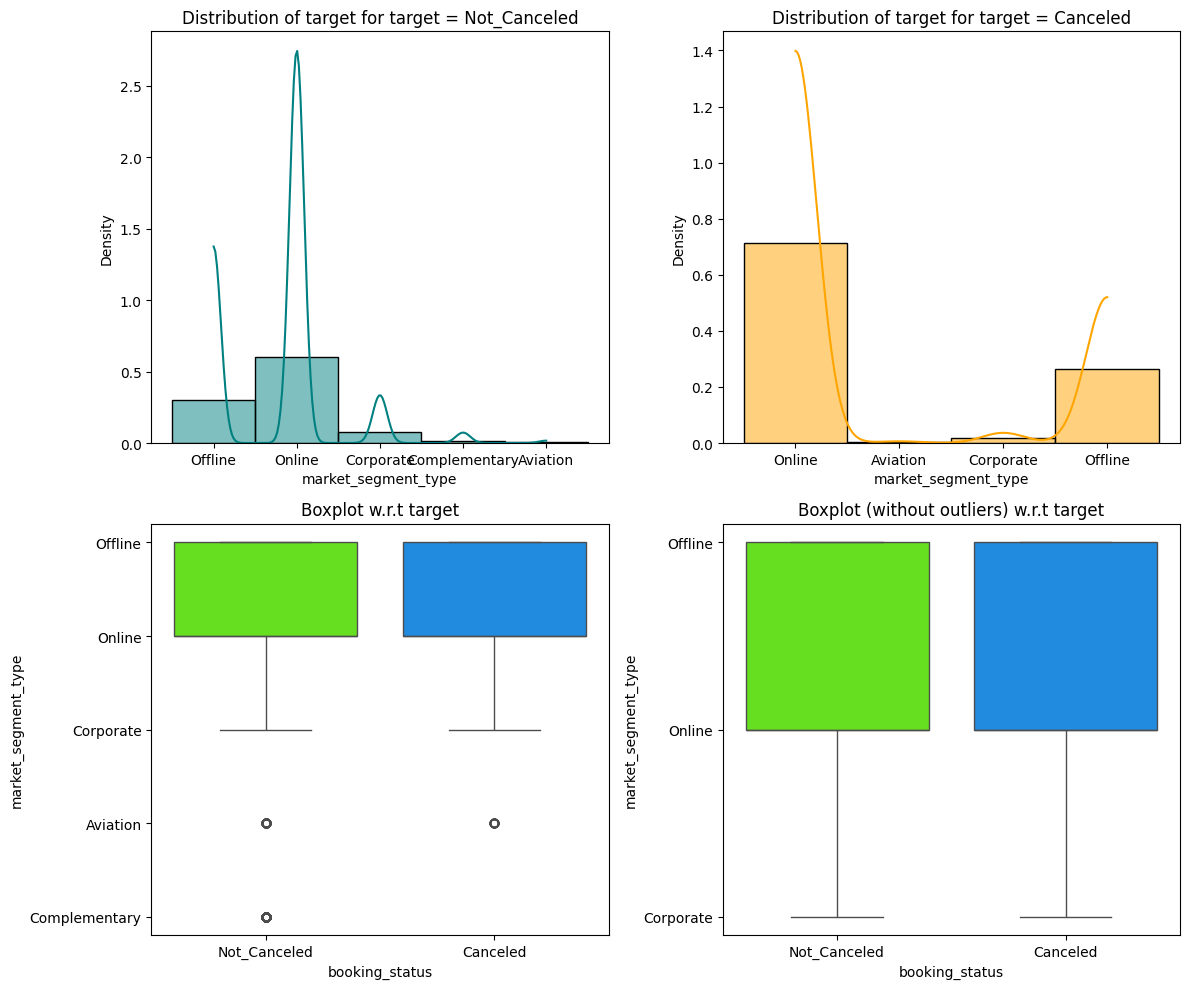

In [ ]:
distribution_plot_wrt_target(data, "market_segment_type")

- There is no relationship between booking_status and market segment type

### Observations on booking_Status vs lead_time

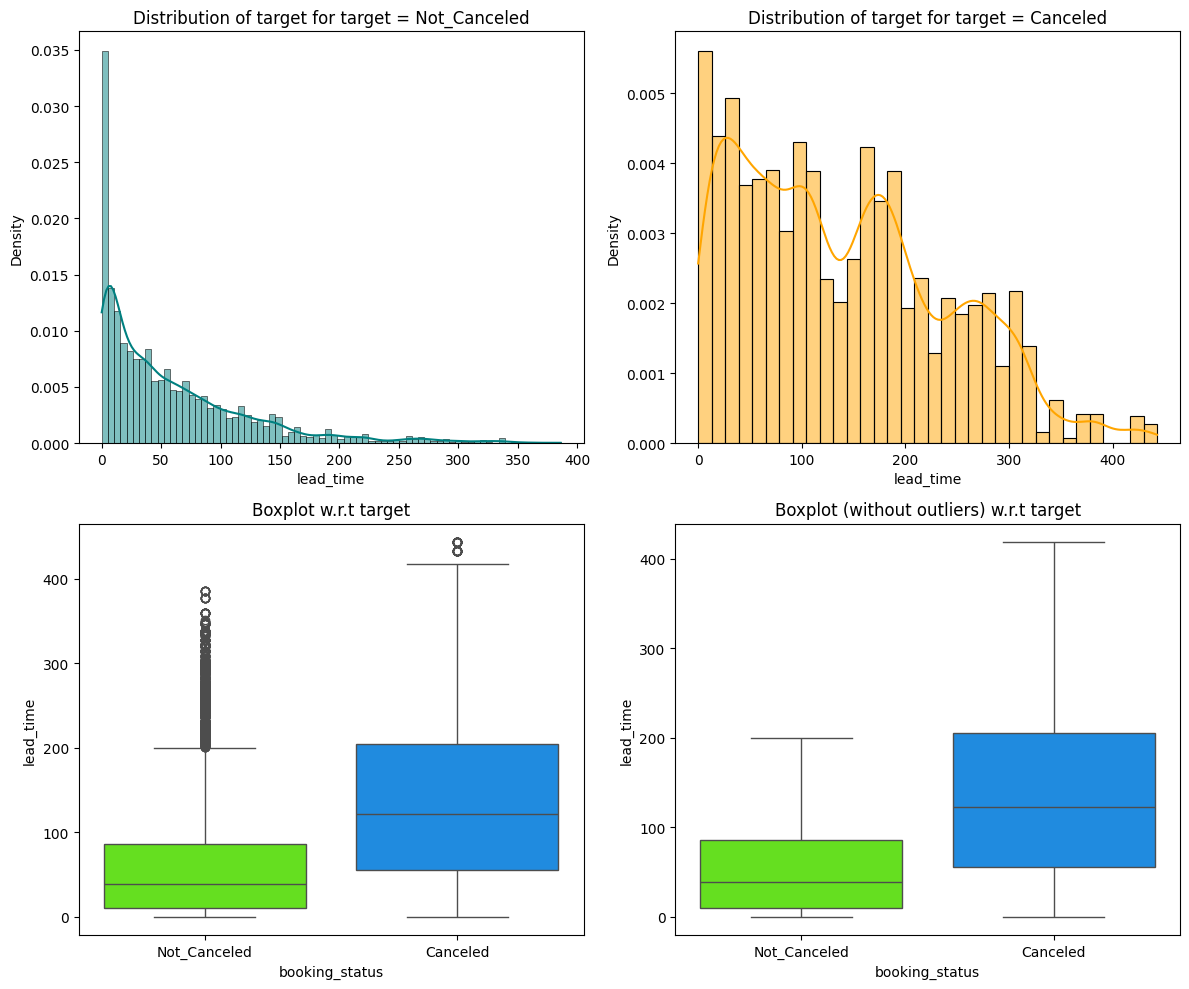

In [ ]:
distribution_plot_wrt_target(data, "lead_time")

- **There is a clear relationship between leadtime and booking status. There are more cancellations when leadtime is longer.**

# **Data Preprocessing**

In [ ]:
data.head().T

,0,1,2,3,4
no_of_adults,2,2,1,2,2
no_of_children,0,0,0,0,0
no_of_weekend_nights,1,2,2,0,1
no_of_week_nights,2,3,1,2,1
type_of_meal_plan,Meal Plan 1,Not Selected,Meal Plan 1,Meal Plan 1,Not Selected
room_type_reserved,Room_Type 1,Room_Type 1,Room_Type 1,Room_Type 1,Room_Type 1
lead_time,224,5,1,211,48
arrival_year,2017,2018,2018,2018,2018
arrival_month,10,11,2,5,4
arrival_date,2,6,28,20,11


### Outlier treatment

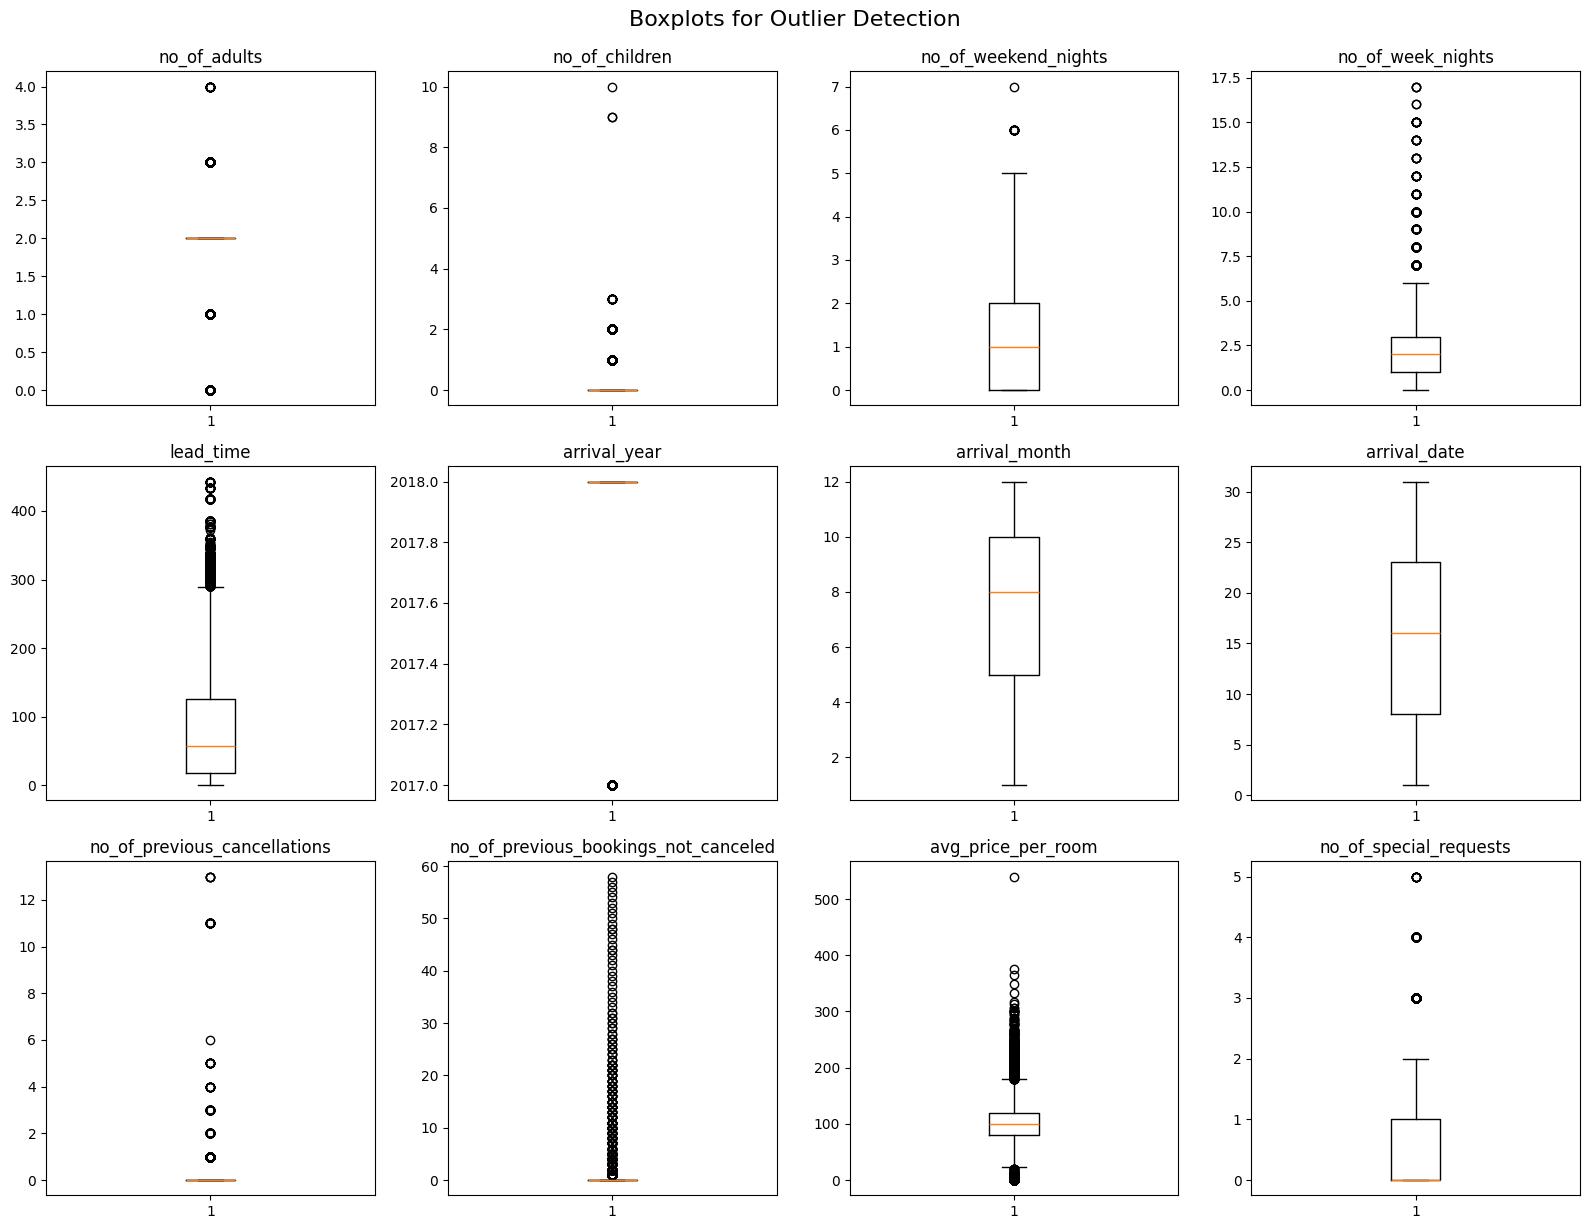

In [ ]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

# Drop any non-feature numeric column (e.g., if 'target' or ID exists)
columns_to_exclude = ["booking_id"]  # Add other irrelevant numeric cols if needed
numeric_columns = [col for col in numeric_columns if col not in columns_to_exclude]

#  Plot boxplots for each numeric variable
plt.figure(figsize=(16, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(int(np.ceil(len(numeric_columns) / 4)), 4, i + 1)
    plt.boxplot(data[variable].dropna(), whis=1.5)
    plt.title(variable)
    plt.tight_layout()

plt.suptitle("Boxplots for Outlier Detection", fontsize=16, y=1.02)
plt.show()

**Observations**

- There are quite a few outliers in the data.
- we will not treat them in the next step as they are proper values

# **Data Preparation And Data modeling**

- We want to predict which feature is more likely to affect the booking cancellation.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

#### First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    prob_pred = model.predict(predictors)
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]

    acc = accuracy_score(target, class_pred)  # to compute Accuracy
    recall = recall_score(target, class_pred)  # to compute Recall
    precision = precision_score(target, class_pred)  # to compute Precision
    f1 = f1_score(target, class_pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    prob_pred = model.predict(predictors)
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]
    cm = confusion_matrix(target, class_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Defining features and Onehot-Encoding

In [ ]:
# Encode target
Y = data["booking_status"].map({'Canceled': 1, 'Not_Canceled': 0})

# Feature prep
X = data.drop(["booking_status"], axis=1)
X = pd.get_dummies(X, columns=["type_of_meal_plan", "room_type_reserved", "market_segment_type"], drop_first=True)
X = X.astype(float)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=0)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)
X_train.reset_index(drop=True, inplace=True)

# Add intercept for statsmodels
import statsmodels.api as SM
X_train_const = SM.add_constant(X_train)


In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 25)
Shape of test set :  (10883, 25)
Percentage of classes in training set:
booking_status
0    0.672692
1    0.327308
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0    0.671598
1    0.328402
Name: proportion, dtype: float64


# **Logistic Regression (with Statsmodel)**

In [ ]:
print(data['booking_status'].unique())

['Not_Canceled' 'Canceled']


In [ ]:
Y = data['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})
print(Y.unique())  # should now show: [0, 1]

[0 1]


In [ ]:
X_train = X_train.loc[:, ~X_train.T.duplicated()] # To drop any duplicates

### Scaling the Data

In [ ]:
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)

In [ ]:
# Adding constant to data for Logistic Regression
X_train_with_intercept = SM.add_constant(X_train_scaled)
X_test_with_intercept = SM.add_constant(X_test_scaled)

In [ ]:
    # Fit logistic regression model
X_train_const = SM.add_constant(X_train, has_constant='add')

LogisticReg = SM.Logit(y_train, X_train_with_intercept).fit()
print(LogisticReg.summary())

         Current function value: 0.426100
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25366
Method:                           MLE   Df Model:                           25
Date:                Sun, 06 Jul 2025   Pseudo R-squ.:                  0.3261
Time:                        15:17:02   Log-Likelihood:                -10820.
converged:                      False   LL-Null:                       -16054.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.5171     93.480     -0.016      0.987    -184.734

Inferences:
- Positive & significant influence indicates likely strong predictors that increase the odds of cancellation.
- Mixed influence, all significant influence says some positively, some negatively affect outcome.
- Strong negative coefficients, highly significant says likely dummies or encoded categories that decrease cancellation odds drastically


### Checking Logistic Regression model performance on training set

In [ ]:
y_pred = LogisticReg.predict(X_train_with_intercept)
y_pred.head()

,0
0,0.290203
1,0.751926
2,0.347403
3,0.518186
4,0.764589


In [ ]:
logistic_reg_perf_train = model_performance_classification(
    LogisticReg, X_train_with_intercept, y_train
)
logistic_reg_perf_train

,Accuracy,Recall,Precision,F1
0,0.804387,0.627,0.736225,0.677237


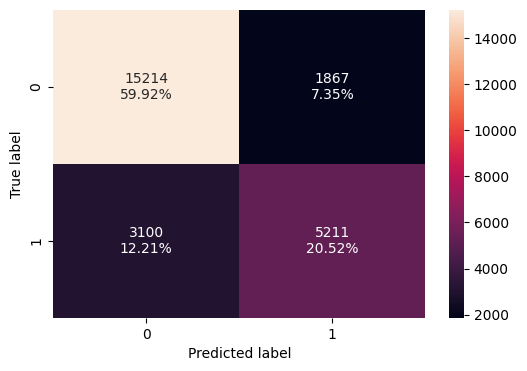

In [ ]:
plot_confusion_matrix(LogisticReg, X_train_with_intercept, y_train)

### Checking Logistic Regression model performance on test set

In [ ]:
# Function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance for statsmodels Logit

    model: statsmodels classifier (fitted Logit model)
    predictors: independent variables (DataFrame)
    target: dependent variable (Series)
    threshold: probability threshold for positive class prediction (default is 0.5)
    """

    # predicting using the independent variables
    # Statsmodels predict expects the data with a constant if the model was fitted with one
    prob_pred = model.predict(SM.add_constant(predictors, has_constant='add'))
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]

    acc = accuracy_score(target, class_pred)  # to compute Accuracy
    recall = recall_score(target, class_pred)  # to compute Recall
    precision = precision_score(target, class_pred)  # to compute Precision
    f1 = f1_score(target, class_pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],)

    return df_perf

# Function to plot the confusion_matrix with percentages for statsmodels Logit
def plot_confusion_matrix_statsmodels(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages for statsmodels Logit

    model: statsmodels classifier (fitted Logit model)
    predictors: independent variables (DataFrame)
    target: dependent variable (Series)
    threshold: probability threshold for positive class prediction (default is 0.5)
    """
    # predicting using the independent variables
    # Statsmodels predict expects the data with a constant if the model was fitted with one
    prob_pred = model.predict(SM.add_constant(predictors, has_constant='add'))
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]
    cm = confusion_matrix(target, class_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()


# Now, call the correct function for the statsmodels model
logistic_reg_perf_test = model_performance_classification_statsmodels(
    LogisticReg, X_test_scaled, y_test
)
logistic_reg_perf_test

,Accuracy,Recall,Precision,F1
0,0.801617,0.624231,0.732196,0.673916


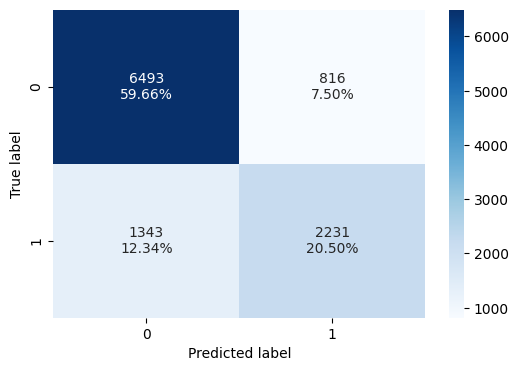

In [ ]:
plot_confusion_matrix_statsmodels(LogisticReg, X_test_scaled, y_test)

- The Logistic Regression model has a average performance on both training and test sets

## Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Checking Decision Tree Classifier performance on training set

In [ ]:
decision_tree_perf_train = model_performance_classification(
    dt_model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.994683,0.987246,0.996478,0.99184


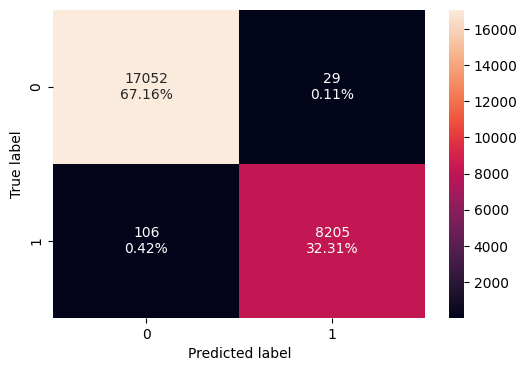

In [ ]:
plot_confusion_matrix(dt_model, X_train, y_train)

* Almost 0 errors on the training set, each sample has been classified correctly.
* Model has performed very well on the training set.
* As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.
* Let's check the performance on test data to see if the model is overfitting

### Checking Decision Tree Classifier performance on test set

In [ ]:
decision_tree_perf_test = model_performance_classification(
    dt_model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.864008,0.797426,0.790349,0.793872


**Observations**

- The f1_score of the model is ~0.79 and we will try to maximize it further

- The variables used to build the model might contain multicollinearity, which will affect the p-values

* We will have to remove multicollinearity from the data to get reliable coefficients and p-values

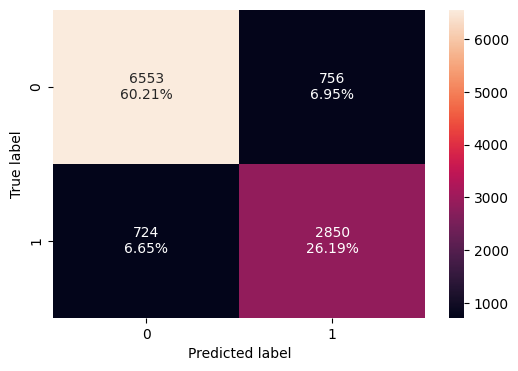

In [ ]:
plot_confusion_matrix(dt_model, X_test, y_test)

* The decision tree model is overfitting the data as expected and not able to generalize well on the test set.
* We will have to prune the decision tree.

# **Model Performance Improvement**

## Logistic Regression (deal with multicollinearity, remove high p-value variables, determine optimal threshold 	using ROC curve)

## Model evaluation criterion:

**Model can make wrong predictions as**:

Predicting a booking cancellations as not cancelled and not cancelled as cancellations


**Which case is more important?**

  * If we predict a guest does cancel, but the model predicts they will not. we might hold a room unnecessarily,turn away other potential guests, lose revenue due to last-minute vacancy. We may also lost opportunity and unpreparedness.This is called False negatives.

  * If we predict a guest didnot cancel as canceled, we can offer the room to others, overbook to compensate. This is called False positive.

**predicting a cancellation as not canceled (false negative) is worse, because it can as it leads to unsold inventory, reduces revenue and disruptive planning. **

**How to reduce this loss?**

* We need to reduce False Negatives

* `f1_score` should be maximized as the greater the f1_score, the higher the chances of reducing False Negatives
  * fi_score is computed as
  $$f1\_score = \frac{2 * Precision * Recall}{Precision + Recall}$$

### Detecting and Dealing with Multicollinearity

There are different ways of detecting (or testing for) multicollinearity. One such way is using the Variation Inflation Factor (VIF).

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of thumb**:
  - If VIF is 1 then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence  the variance of $\beta_k$ is not inflated at all
  - If VIF exceeds 5, we say there is moderate multicollinearity
  - If VIF is equal or exceeding 10, it shows signs of high multi-collinearity


In [ ]:
def calculate_vif(idf):
    """
    Calculate Variance Inflation Factor (VIF) for each variable in a DataFrame.

    Parameters:
    df (DataFrame): Input DataFrame containing numerical variables.

    Returns:
    vif_df (DataFrame): DataFrame containing variable names and their corresponding VIF values.
    """
    variables = idf.values
    vif_df = pd.DataFrame()
    vif_df["Variable"] = idf.columns
    vif_df["VIF"] = [variance_inflation_factor(variables, i) for i in range(idf.shape[1])]
    return vif_df

In [ ]:
# Call the function to calculate VIF
vif_result = calculate_vif(X_train_with_intercept)

print("Variance Inflation Factors:")
print(vif_result)

Variance Inflation Factors:
                                Variable        VIF
0                                  const   1.000000
1                           no_of_adults   1.336793
2                         no_of_children   2.022270
3                   no_of_weekend_nights   1.072002
4                      no_of_week_nights   1.095914
5                              lead_time   1.389395
6                           arrival_year   1.422584
7                          arrival_month   1.266127
8                           arrival_date   1.005737
9           no_of_previous_cancellations   1.291195
10  no_of_previous_bookings_not_canceled   1.431109
11                    avg_price_per_room   2.014157
12                no_of_special_requests   1.250826
13         type_of_meal_plan_Meal Plan 2   1.269991
14         type_of_meal_plan_Meal Plan 3   1.023978
15        type_of_meal_plan_Not Selected   1.271113
16        room_type_reserved_Room_Type 2   1.104744
17        room_type_reserved_Room_Ty

- market_segment_type_Online shows high multicolinearity too with VIF 69.9 and market_segment_type_Offline shows VIF 63.3.
-market_segment_type_Corporate shows moderate VIF as 16.74

In [ ]:
# Dropping columns with VIF > 5 iteratively
while vif_result['VIF'].max() > 5:
    high_vif_column = vif_result.loc[vif_result['VIF'].idxmax(), 'Variable']
    print(f"Dropping {high_vif_column} due to high VIF")
    X_train_scaled.drop(columns=high_vif_column, inplace=True)
    X_test_scaled.drop(columns=high_vif_column, inplace=True)
    vif_result = calculate_vif(X_train_scaled)

Dropping market_segment_type_Online due to high VIF


### Removing high p-value variables
- we will drop variables with high p-value one by one iteratively by using a loop
- This loop will repeat the steps for all the variables with p-value > 0.05

In [ ]:
# Start with full set of features
cols = predictors.columns.tolist()

# Always keep 'const' safe
if 'const' not in cols:
    predictors = sm.add_constant(predictors, has_constant='add')
    cols = predictors.columns.tolist()

# Backward elimination loop
while True:
    x_train_aux = predictors[cols]
    model = SM.Logit(y_train, x_train_aux).fit(disp=False)

    # Exclude 'const' when evaluating p-values
    p_values = model.pvalues.drop('const')

    if p_values.empty:
        break

    max_p_value = p_values.max()
    feature_with_max_p = p_values.idxmax()

    print(f"Dropping {feature_with_max_p} with p-value {max_p_value:.4f}")

    if max_p_value > 0.05:
        cols.remove(feature_with_max_p)
    else:
        break

selected_features = cols
print(f"\n Final selected features:\n{selected_features}")

Dropping type_of_meal_plan_Meal Plan 3 with p-value 0.9976
Dropping market_segment_type_Complementary with p-value 0.9977
Dropping room_type_reserved_Room_Type 3 with p-value 0.8354
Dropping arrival_date with p-value 0.3085
Dropping market_segment_type_Online with p-value 0.1236
Dropping no_of_previous_cancellations with p-value 0.0949
Dropping type_of_meal_plan_Meal Plan 2 with p-value 0.0787
Dropping no_of_adults with p-value 0.0088

✅ Final selected features:
['const', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'lead_time', 'arrival_year', 'arrival_month', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Corporate', 'market_segment_type_Offline']


In [ ]:
# Add constant if not present already
if 'const' not in X_train_with_intercept.columns:
    X_train_with_intercept = SM.add_constant(X_train_with_intercept, has_constant='add')

if 'const' not in X_test_with_intercept.columns:
    X_test_with_intercept = SM.add_constant(X_test_with_intercept, has_constant='add')

# Now subset safely
X_train_significant = X_train_with_intercept[selected_features]
X_test_significant = X_test_with_intercept[selected_features]

# Preview
X_train_significant.head(10)

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,arrival_year,arrival_month,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
0,1.0,0.305009,-0.260385,1.370793,-0.852818,0.044917,0.471234,-1.116495,-0.092282,-0.678263,0.490168,2.464342,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
1,1.0,0.305009,-0.260385,-0.928380,-0.139529,2.594228,0.471234,1.161819,-0.092282,-1.465036,-0.783116,-0.405788,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,1.554682
2,1.0,-1.632154,-0.260385,1.370793,-0.852818,-0.758291,0.471234,-1.441968,-0.092282,-0.520909,-0.783116,-0.405788,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
3,1.0,0.305009,-0.260385,-0.928380,2.000341,1.686254,0.471234,0.510872,-0.092282,0.966807,0.490168,-0.405788,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,1.554682
4,1.0,0.305009,-0.260385,1.370793,-0.139529,-0.059849,0.471234,0.510872,-0.092282,0.935336,-0.783116,-0.405788,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
5,1.0,0.305009,-0.260385,1.370793,-0.139529,-0.723368,0.471234,1.487292,-0.092282,0.868102,0.490168,-0.405788,-0.139397,2.244666,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
6,1.0,0.305009,-0.260385,-0.928380,0.573761,-0.478914,0.471234,0.185399,-0.092282,1.553310,-0.783116,-0.405788,-0.139397,2.244666,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
7,1.0,0.305009,-0.260385,-0.928380,-0.139529,-0.304304,0.471234,-1.441968,-0.092282,-1.021582,-0.783116,2.464342,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
8,1.0,0.305009,-0.260385,0.221207,-0.139529,-0.024927,0.471234,-0.465548,-0.092282,0.592017,-0.783116,-0.405788,-0.139397,-0.445501,-0.088651,-0.165757,-0.068329,-0.243566,-0.643218
9,1.0,0.305009,-0.260385,1.370793,2.000341,0.079839,0.471234,-1.441968,-0.092282,-1.465036,-0.783116,-0.405788,-0.139397,2.244666,-0.088651,-0.165757,-0.068329,-0.243566,1.554682


### Training the Logistic Regression model again with only the significant features

In [ ]:
LogisticReg_tuned = SM.Logit(y_train, X_train_significant).fit()
print(LogisticReg_tuned.summary())

Optimization terminated successfully.
         Current function value: 0.426831
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25373
Method:                           MLE   Df Model:                           18
Date:                Sun, 06 Jul 2025   Pseudo R-squ.:                  0.3249
Time:                        16:15:22   Log-Likelihood:                -10838.
converged:                       True   LL-Null:                       -16054.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.1643      0.

### Determining optimal threshold using ROC Curve

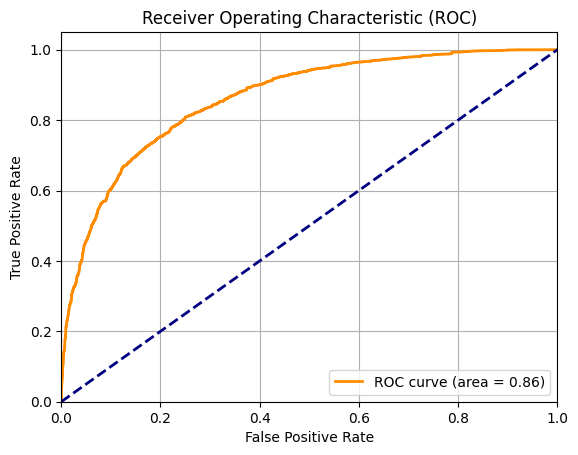

In [ ]:
y_pred = LogisticReg_tuned.predict(X_train_significant)
fpr, tpr, thresholds = roc_curve(y_train, y_pred)

# Plot ROC curve
roc_auc = roc_auc_score(y_train, y_pred)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
# Find the optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_logit = round(thresholds[optimal_idx], 3)
print("\nOptimal Threshold: ", optimal_threshold_logit)


Optimal Threshold:  0.289


### Checking tuned Logistic Regression model performance on training set

In [ ]:
logistic_reg_tune_perf_train = model_performance_classification(
    LogisticReg_tuned, X_train_significant, y_train, optimal_threshold_logit
)
logistic_reg_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.768982,0.808326,0.611227,0.696094


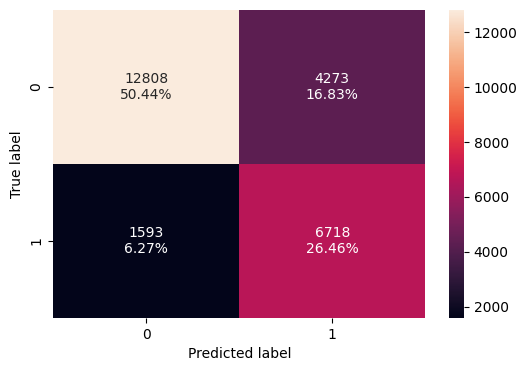

In [ ]:
plot_confusion_matrix(LogisticReg_tuned, X_train_significant, y_train, optimal_threshold_logit)

### Checking tuned Logistic Regression model performance on test set

In [ ]:
logistic_reg_tune_perf_test = model_performance_classification(
    LogisticReg_tuned, X_test_significant, y_test, optimal_threshold_logit
)

logistic_reg_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.764679,0.810856,0.605896,0.69355


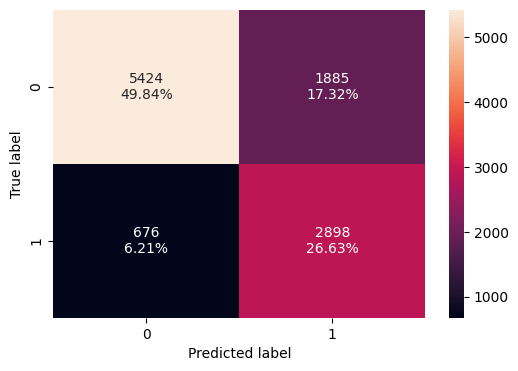

In [ ]:
plot_confusion_matrix(LogisticReg_tuned, X_test_significant, y_test, optimal_threshold_logit)

* The performance of the Logistic Regression model not changed (on both training and test sets) by dropping variables with high p-values and setting an optimal threshold.

## Decision Tree Classifier (pre-pruning and post-pruning)

### Pre - pruning the tree

In [ ]:
# Choose the type of classifier.
dt_model_tuned_1 = DecisionTreeClassifier(random_state=42)

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(5, 13, 2),                          ## Max Depth of the decision tree
    "max_leaf_nodes": [10, 20, 40, 50, 75, 100],               ## Maximum number of leaf nodes
    "min_samples_split": [2, 5, 7, 10, 20, 30],                ## Minimum number of samples required to split an internal node
    "class_weight": ['balanced', None]                         ## whether or not to used balanced weights for impurity computations
}

# Run the grid search
grid_obj = GridSearchCV(dt_model_tuned_1, parameters, scoring='recall', cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dt_model_tuned_1 = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dt_model_tuned_1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(9),
                       max_leaf_nodes=100, min_samples_split=30,
                       random_state=42)

### Checking pre-pruned Decision Tree Classifier performance on training set

In [ ]:
dt_model_tuned_1_perf_train = model_performance_classification(
    dt_model_tuned_1, X_train, y_train
)
dt_model_tuned_1_perf_train

,Accuracy,Recall,Precision,F1
0,0.857908,0.840452,0.75375,0.794743


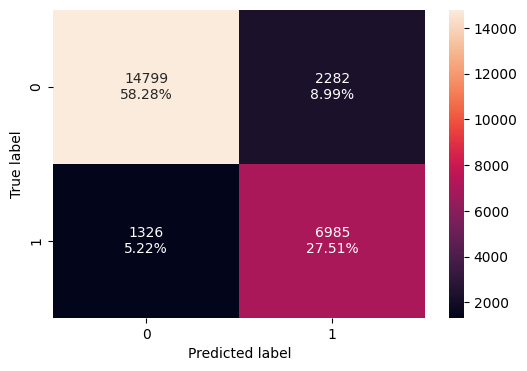

In [ ]:
plot_confusion_matrix(dt_model_tuned_1, X_train, y_train)

### Checking pre-pruned Decision Tree Classifier performance on test set

---


In [ ]:
dt_model_tuned_1_perf_test = model_performance_classification(
    dt_model_tuned_1, X_test, y_test
)
dt_model_tuned_1_perf_test

,Accuracy,Recall,Precision,F1
0,0.853441,0.828483,0.750951,0.787814


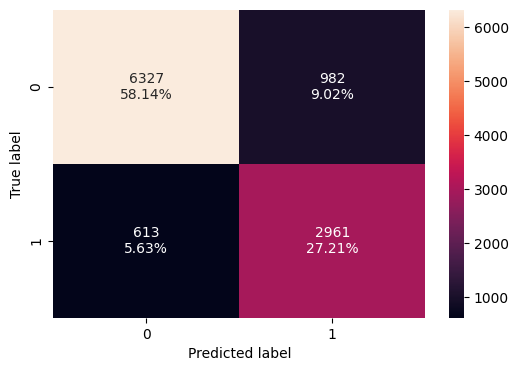

In [ ]:
plot_confusion_matrix(dt_model_tuned_1, X_test, y_test)

### Visualizing the Decision Tree

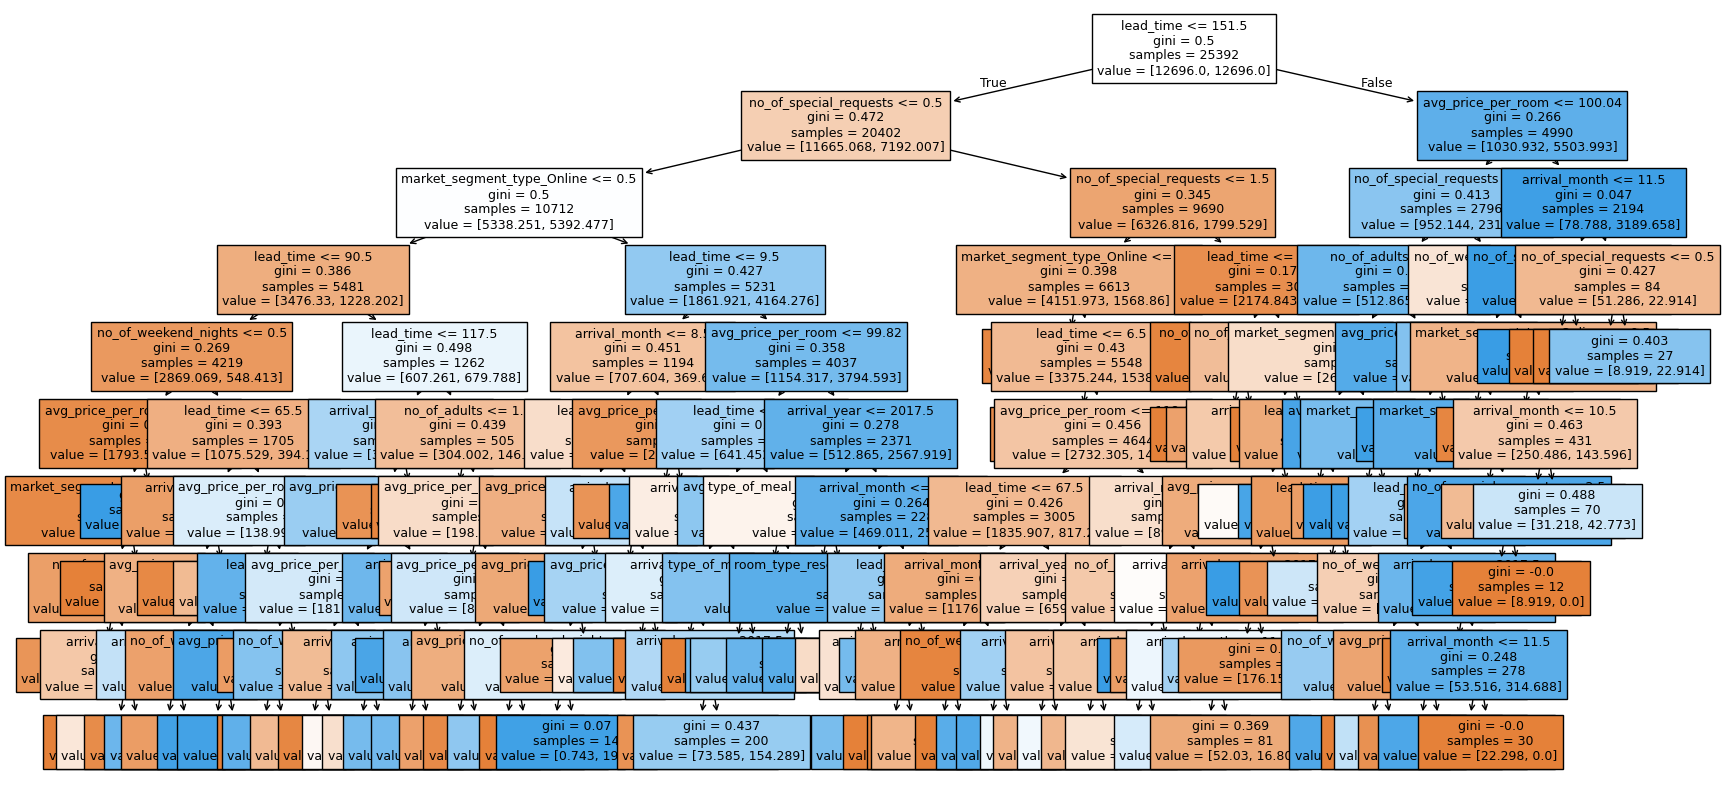

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    dt_model_tuned_1,
    feature_names=X_train.columns.tolist(),
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

### Analyzing Feature Importance for tuned Decision Tree Classifier

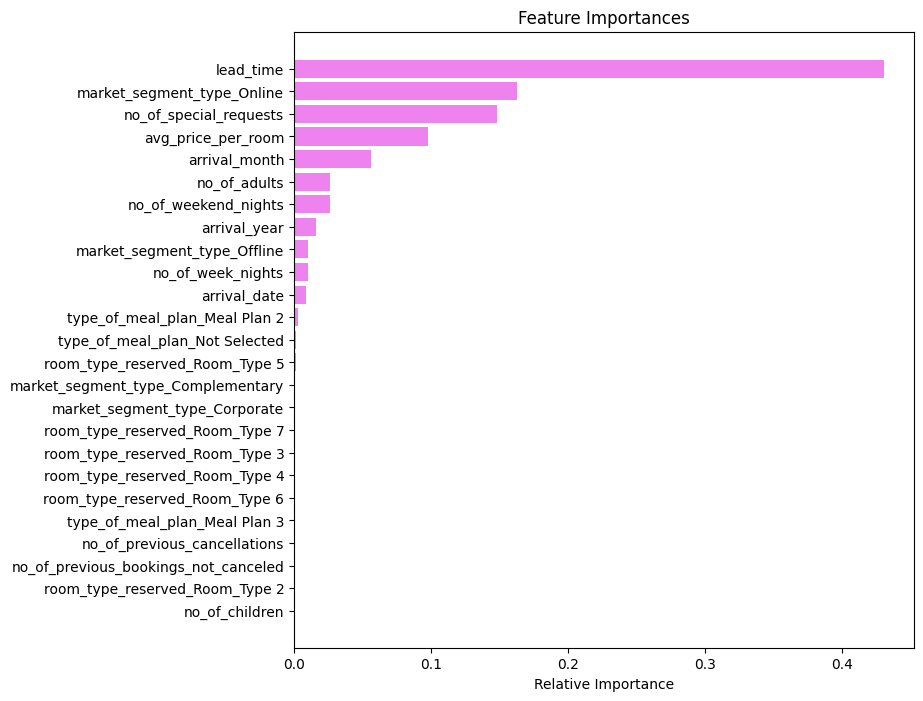

In [ ]:
# importance of features in the tree building

feature_names = X_train.columns.tolist()
importances = dt_model_tuned_1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Post - pruning the tree

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.007113
1,1.842455e-07,0.007113
2,3.811208e-07,0.007113
3,3.952364e-07,0.007114
4,4.453017e-07,0.007114
...,...,...
1349,7.079816e-03,0.288491
1350,1.248946e-02,0.300981
1351,1.626436e-02,0.317245
1352,2.344453e-02,0.364134


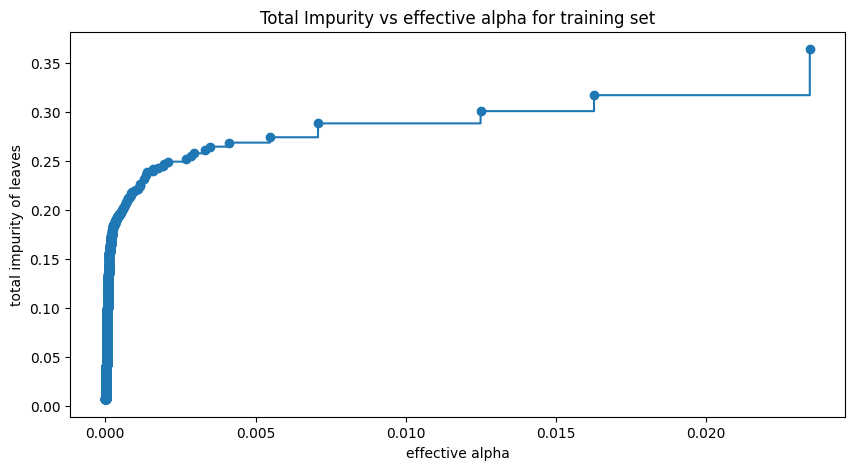

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Sanity-check: trim ccp_alphas if large
ccp_alphas = ccp_alphas[:20]

dt_models = []
for i, ccp_alpha in enumerate(ccp_alphas):
    print(f"Fitting model {i+1} with ccp_alpha = {ccp_alpha:.6f}...")
    model = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    dt_models.append(model)

print(f"\n✅ Number of nodes in last tree: {dt_models[-1].tree_.node_count} with ccp_alpha: {ccp_alphas[-1]}")

Fitting model 1 with ccp_alpha = 0.000000...
Fitting model 2 with ccp_alpha = 0.000000...
Fitting model 3 with ccp_alpha = 0.000000...
Fitting model 4 with ccp_alpha = 0.000000...
Fitting model 5 with ccp_alpha = 0.000000...
Fitting model 6 with ccp_alpha = 0.000001...
Fitting model 7 with ccp_alpha = 0.000001...
Fitting model 8 with ccp_alpha = 0.000001...
Fitting model 9 with ccp_alpha = 0.000001...
Fitting model 10 with ccp_alpha = 0.000001...
Fitting model 11 with ccp_alpha = 0.000001...
Fitting model 12 with ccp_alpha = 0.000002...
Fitting model 13 with ccp_alpha = 0.000002...
Fitting model 14 with ccp_alpha = 0.000002...
Fitting model 15 with ccp_alpha = 0.000002...
Fitting model 16 with ccp_alpha = 0.000002...
Fitting model 17 with ccp_alpha = 0.000003...
Fitting model 18 with ccp_alpha = 0.000003...
Fitting model 19 with ccp_alpha = 0.000003...
Fitting model 20 with ccp_alpha = 0.000004...

✅ Number of nodes in last tree: 5923 with ccp_alpha: 4.430529300567063e-06


For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

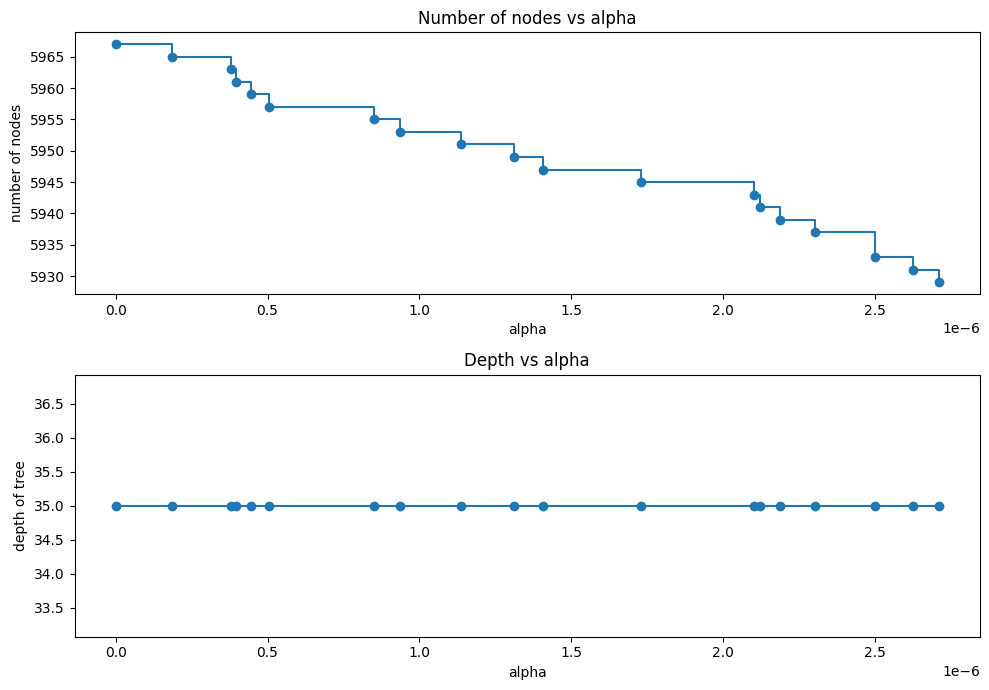

In [ ]:
dt_models = dt_models[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [dt_model.tree_.node_count for dt_model in dt_models]
depth = [dt_model.tree_.max_depth for dt_model in dt_models]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Recall vs alpha for training and test sets

In [ ]:
from sklearn.metrics import recall_score

recall_train = []
for dt_model in dt_models:
    pred_train = dt_model.predict(X_train)
    score = recall_score(y_train, pred_train)
    recall_train.append(score)

recall_test = []
for dt_model in dt_models:
    pred_test = dt_model.predict(X_test)
    score = recall_score(y_test, pred_test)
    recall_test.append(score)

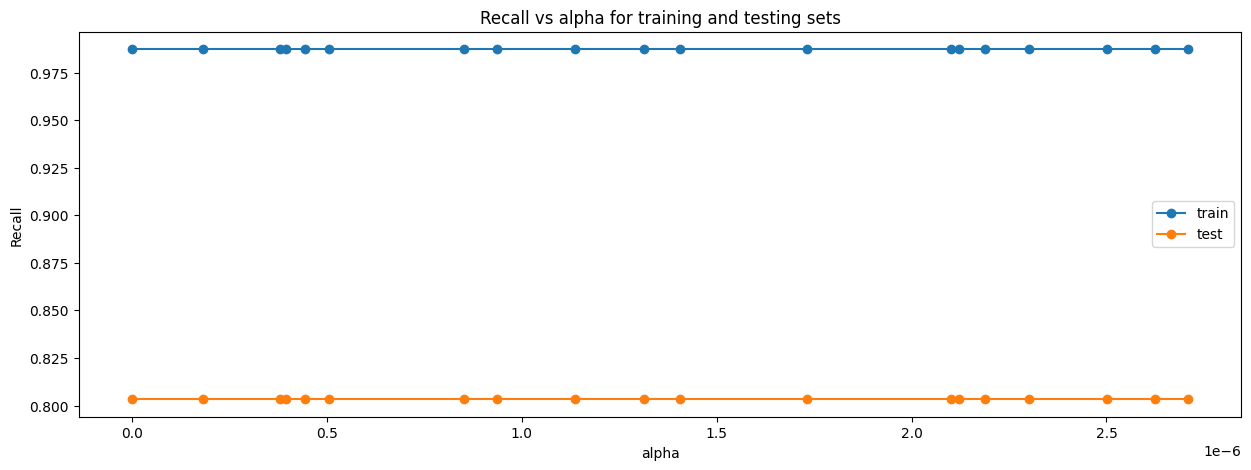

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
index_best_model = np.argmax(recall_test)
dt_model_post_pruned = dt_models[index_best_model]
print(dt_model_post_pruned)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=1)


- No matter how much pruning you apply (ccp_alpha), recall on the training set remains extremely high, but the testing set recall does not improve

In [ ]:
dt_model_tuned_2 = DecisionTreeClassifier(
    ccp_alpha=ccp_alpha, class_weight={0: 0.126, 1: 0.874}, random_state=1
)
dt_model_tuned_2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(4.430529300567063e-06),
                       class_weight={0: 0.126, 1: 0.874}, random_state=1)

### Checking post-pruned Decision Tree Classifier performance on training set

In [ ]:
dt_model_tuned_2_perf_train = model_performance_classification(dt_model_tuned_2, X_train, y_train)
dt_model_tuned_2_perf_train

,Accuracy,Recall,Precision,F1
0,0.990233,0.998797,0.972128,0.985282


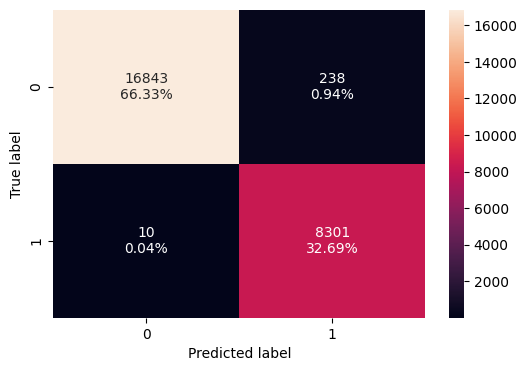

In [ ]:
plot_confusion_matrix(dt_model_tuned_2, X_train, y_train)

### Checking post-pruned Decision Tree Classifier performance on test set

In [ ]:
dt_model_tuned_2_perf_test = model_performance_classification(dt_model_tuned_2, X_test, y_test)
dt_model_tuned_2_perf_test

,Accuracy,Recall,Precision,F1
0,0.865846,0.801903,0.79215,0.796997


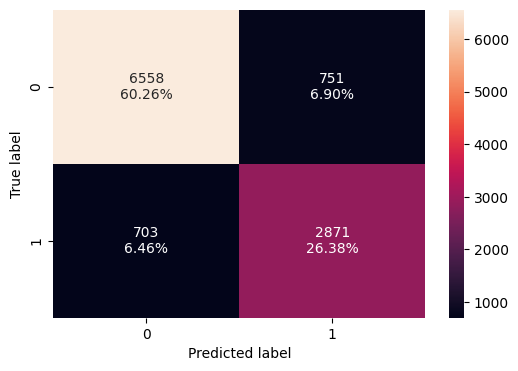

In [ ]:
plot_confusion_matrix(dt_model_post_pruned, X_test, y_test)  # Complete the code to get the confusion matrix on test data

### Visualizing the Decision Tree

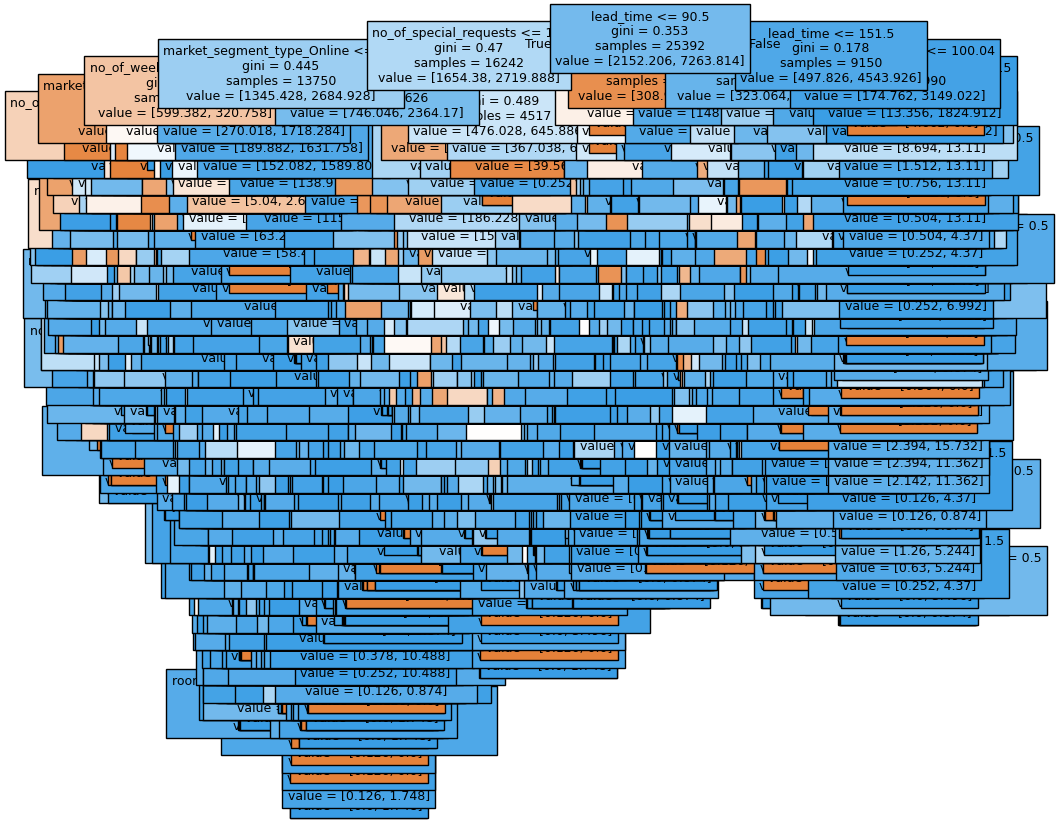

In [ ]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    dt_model_tuned_2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dt_model_tuned_2, feature_names=feature_names, show_weights=True))

|--- lead_time <= 90.50
|   |--- no_of_special_requests <= 1.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |--- no_of_previous_bookings_not_canceled <= 0.50
|   |   |   |   |   |   |--- avg_price_per_room <= 65.50
|   |   |   |   |   |   |   |--- avg_price_per_room <= 57.50
|   |   |   |   |   |   |   |   |--- weights: [14.24, 0.00] class: 0
|   |   |   |   |   |   |   |--- avg_price_per_room >  57.50
|   |   |   |   |   |   |   |   |--- lead_time <= 3.50
|   |   |   |   |   |   |   |   |   |--- arrival_year <= 2017.50
|   |   |   |   |   |   |   |   |   |   |--- arrival_date <= 22.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- arrival_date >  22.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.63, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- arrival_year > 

### Analyzing Feature Importance for tuned Decision Tree Classifier

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        dt_model_tuned_2.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                                           Imp
lead_time                             0.278198
no_of_special_requests                0.136918
avg_price_per_room                    0.135296
market_segment_type_Online            0.091999
arrival_month                         0.088887
arrival_date                          0.085083
no_of_week_nights                     0.050580
no_of_weekend_nights                  0.039889
no_of_adults                          0.024444
market_segment_type_Offline           0.015714
arrival_year                          0.014325
type_of_meal_plan_Not Selected        0.008637
room_type_reserved_Room_Type 4        0.008374
no_of_children                        0.006648
no_of_previous_bookings_not_canceled  0.005919
type_of_meal_plan_Meal Plan 2         0.003228
room_type_reserved_Room_Type 2        0.002091
market_segment_type_Corporate         0.001920
room_type_reserved_Room_Type 5        0.000989
room_type_reserved_Room_Type 6        0.000405
room_type_res

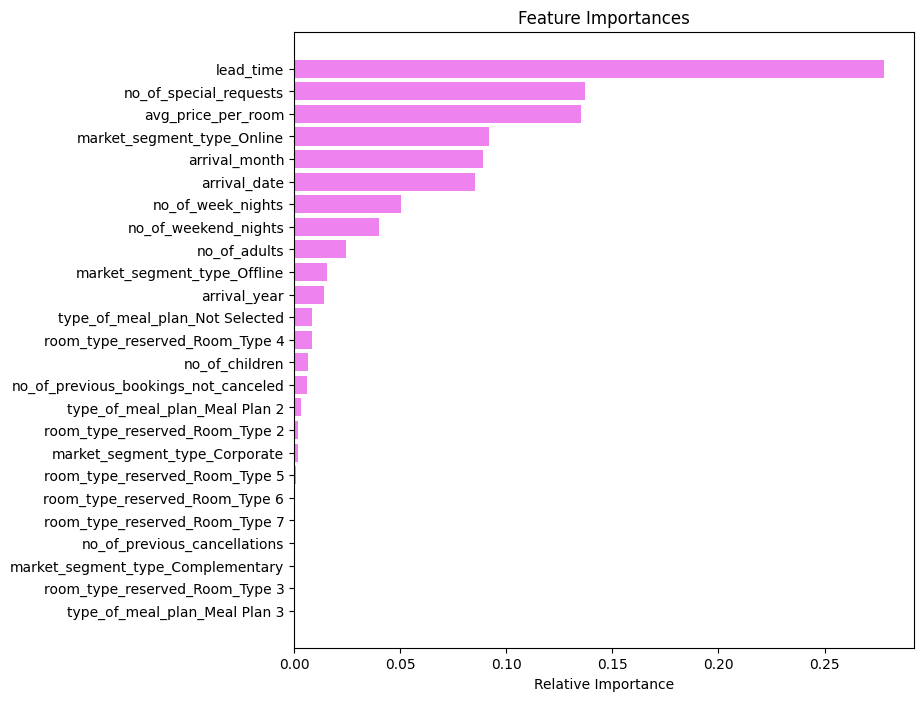

In [ ]:
importances = dt_model_tuned_2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        logistic_reg_perf_train.T,
        logistic_reg_tune_perf_train.T,
        decision_tree_perf_train.T,
        dt_model_tuned_1_perf_train.T,
        dt_model_tuned_2_perf_train.T
            ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression Base",
    "Logistic Regression Improved",
    "Decision Tree Base",
    "Decision Tree Pre-Pruned",
    "Decision Tree Post-Pruned"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression Base,Logistic Regression Improved,Decision Tree Base,Decision Tree Pre-Pruned,Decision Tree Post-Pruned
Accuracy,0.804387,0.768982,0.994683,0.857908,0.990233
Recall,0.627000,0.808326,0.987246,0.840452,0.998797
Precision,0.736225,0.611227,0.996478,0.753750,0.972128
F1,0.677237,0.696094,0.991840,0.794743,0.985282


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        logistic_reg_perf_test.T,
        logistic_reg_tune_perf_test.T,
        decision_tree_perf_test.T,
        dt_model_tuned_1_perf_test.T,
        dt_model_tuned_2_perf_test.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression Base",
    "Logistic Regression Tuned",
    "Decision Tree Base",
    "Decision Tree Pre-Pruned",
    "Decision Tree Post-Pruned"
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Regression Base,Logistic Regression Tuned,Decision Tree Base,Decision Tree Pre-Pruned,Decision Tree Post-Pruned
Accuracy,0.801617,0.764679,0.864008,0.853441,0.865846
Recall,0.624231,0.810856,0.797426,0.828483,0.801903
Precision,0.732196,0.605896,0.790349,0.750951,0.792150
F1,0.673916,0.693550,0.793872,0.787814,0.796997


**Observations**
* Decision tree model with default parameters is less overfitting the training data and is able to generalize well.
* Pre-pruned tree has given a generalized performance with the recall score of 0.84 and 0.82 on training and test set, respectively.

# **Actionable Insights and Recommendations**

1. logistic regression model and odds ratio analysis reveal that:
- Higher cancellation likelihood is associated with:
 - Longer lead times
 - Higher average room prices
 - More children
 - Meal Plan 2
- Lower cancellation likelihood is strongly tied to:
 - Special requests (most significant protective factor)
 - Repeat bookings
 - Offline and corporate channels
 - Certain room types (Room Type 2, 5, and 6)

2. Threshold Tuning
We evaluated thresholds between 0.25 and 0.5:
- At threshold = 0.25, we achieved maximum recall (~84%), which aligns best with the business objective of minimizing false negatives.
- Despite slightly lower precision, this threshold helps catch more actual cancellations.

Recommendation: Set deployment threshold at 0.25 and inform guests for early confirmations (like confirmation emails or flexible rescheduling offers).

3. Model Comparison
Among logistic regression and decision tree variants:
- Best balanced model: Post-Pruned Decision Tree as it shows high F1-score, precision, and accuracy
- Highest recall: Pre-Pruned Decision Tree (82.8%) and Tuned Logistic (81.1%)Hence,
- Using the Post-Pruned Tree as our main model
- Using Logistic Regression (Tuned) as a secondary model.

4. Recall vs. Tree Complexity
From the ccp_alpha plots:
- Recall on the training set stays high, indicating overfitting
- Test set recall doesnot improve with pruning thus suggesting basic pruning isnot enough

5. Recommendations
- Customer Engagement:
 - Personalize outreach for high-risk segments (long lead time, Meal Plan 2, families with children)
 - Offer incentives (e.g. discounts, flexibility) to guests showing cancellation but high lifetime value
- Operational Policy:
 - Allow more flexible policies or offer confirmations for repeat guests and corporates


--END--